In [18]:
# Import necessary libraries
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [21]:
# User Input Parameters (CHANGE)
date_str = "20260224"  # YYYYMMDD format
start_time = "000000"  # HHMMSS format
end_time = "235959"  # HHMMSS format

# Optional: Set end_time_mask to limit x-axis display (set to None to disable)
# end_time_mask = "145200"  # HHMMSS format - cuts off display at this time
end_time_mask = end_time # for full-day plots

# Base path for acoustic data
base_path = "/Users/xylu/Desktop/Data/acoustic_vpp/"

# Convert strings to datetime objects for filtering
date_obj = datetime.strptime(date_str, "%Y%m%d")
start_time_obj = datetime.strptime(date_str + start_time, "%Y%m%d%H%M%S")
end_time_obj = datetime.strptime(date_str + end_time, "%Y%m%d%H%M%S")

# Convert mask time if provided
if end_time_mask is not None:
    end_time_mask_obj = datetime.strptime(date_str + end_time_mask, "%Y%m%d%H%M%S")
else:
    end_time_mask_obj = None

print(f"Date: {date_str}")
print(f"Time range: {start_time} - {end_time}")
print(f"Start: {start_time_obj.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"End: {end_time_obj.strftime('%Y-%m-%d %H:%M:%S')}")
if end_time_mask_obj:
    print(f"Display mask: {end_time_mask_obj.strftime('%Y-%m-%d %H:%M:%S')}")
    
# Load CSV files for the specified date
print("\n" + "="*60)
print("Looking for CSV files...")
print("="*60)

# Direct path: files are stored in /acoustic_vpp/YYYYMMDD/
date_folder = os.path.join(base_path, date_str)

if not os.path.exists(date_folder):
    print(f"⚠ Folder not found: {date_folder}")
    filtered_df = None
else:
    print(f"✓ Found folder: {date_folder}")
    
    # Find all CSV files matching the date pattern
    csv_files = sorted(glob.glob(os.path.join(date_folder, f"{date_str}*.csv")))
    print(f"  Found {len(csv_files)} CSV file(s)")
    
    if len(csv_files) == 0:
        print(f"⚠ No CSV files found matching {date_str}*.csv")
        filtered_df = None
    else:
        # Load and combine all CSV files
        all_data = []
        
        for csv_file in csv_files:
            try:
                df = pd.read_csv(csv_file)
                # Convert time_datetime to datetime if it's a string (handles microseconds)
                if 'time_datetime' in df.columns:
                    df['time_datetime'] = pd.to_datetime(df['time_datetime'], format='ISO8601')
                all_data.append(df)
                print(f"  ✓ {os.path.basename(csv_file)}: {len(df)} samples")
            except Exception as e:
                print(f"  ✗ Error reading {os.path.basename(csv_file)}: {e}")
        
        if all_data:
            # Combine all data
            combined_df = pd.concat(all_data, ignore_index=True)
            combined_df = combined_df.sort_values('time_datetime').reset_index(drop=True)
            
            print(f"\n✓ Combined data: {len(combined_df)} total samples")
            print(f"  Time range: {combined_df['time_datetime'].min()} to {combined_df['time_datetime'].max()}")
            
            # Filter by time range
            mask = (combined_df['time_datetime'] >= start_time_obj) & (combined_df['time_datetime'] <= end_time_obj)
            filtered_df = combined_df[mask].reset_index(drop=True)
            
            print(f"\n✓ Filtered data (between {start_time_obj.strftime('%H:%M:%S')} and {end_time_obj.strftime('%H:%M:%S')}): {len(filtered_df)} samples")
            
            if len(filtered_df) > 0:
                print(f"  Vpp range: {filtered_df['vpp_volts'].min():.4f} - {filtered_df['vpp_volts'].max():.4f} V")
            else:
                print("  ⚠ No data after filtering by time range")
        else:
            print("⚠ No data loaded!")
            filtered_df = None
            
        
# # Plot Vpp vs Time
# if filtered_df is not None and len(filtered_df) > 0:
#     fig, ax = plt.subplots(figsize=(14, 6))
    
#     ax.plot(filtered_df['time_datetime'], filtered_df['vpp_volts'], linewidth=1, label='Vpp')
#     ax.set_xlabel("Time")
#     ax.set_ylabel("Vpp (Volts)")
#     ax.set_title(f"CH3 Vpp vs Time ({date_str})\n{start_time} - {end_time} ({len(filtered_df)} samples)")
#     ax.grid(True, alpha=0.3)
#     ax.legend()
    
#     # Format x-axis
#     ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
#     ax.tick_params(axis='both', labelsize=12)
#     plt.xticks(rotation=45)
    
#     plt.tight_layout()
#     plt.show()
    
#     # Print statistics
#     print("\n" + "="*60)
#     print("Data Statistics")
#     print("="*60)
#     print(f"Min Vpp: {filtered_df['vpp_volts'].min():.4f} V")
#     print(f"Max Vpp: {filtered_df['vpp_volts'].max():.4f} V")
#     print(f"Mean Vpp: {filtered_df['vpp_volts'].mean():.4f} V")
#     print(f"Median Vpp: {filtered_df['vpp_volts'].median():.4f} V")
#     print(f"Std Dev: {filtered_df['vpp_volts'].std():.4f} V")
#     print(f"Total samples: {len(filtered_df)}")
#     print(f"Duration: {(filtered_df['time_datetime'].max() - filtered_df['time_datetime'].min()).total_seconds()} seconds")
# else:
#     print("No data to plot!")

Date: 20260224
Time range: 000000 - 235959
Start: 2026-02-24 00:00:00
End: 2026-02-24 23:59:59
Display mask: 2026-02-24 23:59:59

Looking for CSV files...
✓ Found folder: /Users/xylu/Desktop/Data/acoustic_vpp/20260224
  Found 288 CSV file(s)
  ✓ 20260224_000000_n_vpp.csv: 6000 samples
  ✓ 20260224_000500_n_vpp.csv: 6000 samples
  ✓ 20260224_001000_n_vpp.csv: 6000 samples
  ✓ 20260224_001500_n_vpp.csv: 6000 samples
  ✓ 20260224_002000_n_vpp.csv: 6000 samples
  ✓ 20260224_002500_n_vpp.csv: 6020 samples
  ✓ 20260224_003000_n_vpp.csv: 6000 samples
  ✓ 20260224_003500_n_vpp.csv: 6000 samples
  ✓ 20260224_004000_n_vpp.csv: 6000 samples
  ✓ 20260224_004500_n_vpp.csv: 6000 samples
  ✓ 20260224_005000_n_vpp.csv: 6000 samples
  ✓ 20260224_005500_n_vpp.csv: 6000 samples
  ✓ 20260224_010000_n_vpp.csv: 6000 samples
  ✓ 20260224_010500_n_vpp.csv: 6000 samples
  ✓ 20260224_011000_n_vpp.csv: 6000 samples
  ✓ 20260224_011500_n_vpp.csv: 6000 samples
  ✓ 20260224_012000_n_vpp.csv: 6000 samples
  ✓ 202602

In [22]:
# Define friendly name mapping (from multi_plot_add_acoustic.ipynb)
pv_mapping = [
    # --- Vacuum Pressure Sensors ---
    ("VALCCG:D01_L01A:PRES", "VAC_D01L01A"),
    ("VALCCG:D01_L02:PRES", "VAC_D01L02"),
    ("VALCCG:D01_L03:PRES", "VAC_D01L03"),
    ("VALCCG:D01_L04:PRES", "VAC_D01L04"),
    ("VALCCG:D04_L01:PRES", "VAC_D4L01"),
    ("VALCCG:D04_L02:PRES", "VAC_D4L02"),
    ("VALCCG:D04_L03:PRES", "VAC_D4L03"),
    ("VALCCG:D04_L04:PRES", "VAC_D4L04"),
    ("VALCCG:D04_L05:PRES", "VAC_D4L05"),
    ("VALCCG:D04_L06:PRES", "VAC_D4L06"),
    ("VALCCG:D04_L07:PRES", "VAC_D4L07"),
    ("VALCCG:D04_L08:PRES", "VAC_D4L08"),
    ("VALCCG:D04_L09:PRES", "VAC_D04L09"),
    ("VALCCG:D05_L18:PRES", "VAC_D05L18"),
    ("VALCCG:D05_L20:PRES", "VAC_D05L20"),
    ("VALCCG:D05_L21:PRES", "VAC_D05L21"),
    ("VALCCG:D05_L22:PRES", "VAC_D05L22"),
    ("VALCCG:D05_L22A:PRES", "VAC_D05L22A"),
    ("VALCCG:D05_L23:PRES", "VAC_D05L23"),
    ("VALCCG:D05_L24:PRES", "VAC_D05L24"),
    ("VALCCG:D05_L25:PRES", "VAC_D05L25"),
    ("VALCCG:D05_L26:PRES", "VAC_D05L26"),
    ("VALCCG:D07_L0:PRES", "VAC_D07L0"),
    ("VALCCG:D07_L00:PRES", "VAC_D07L00"),
    ("VALCCG:D07_L01:PRES", "VAC_D07L01"),
    ("VALCCG:D07_L02:PRES", "VAC_D07L02"),
    ("VALCCG:D07_L03:PRES", "VAC_D07L03"),
    ("VALCCG:D07_L04:PRES", "VAC_D07L04"),
    ("VALCCG:D07_L05:PRES", "VAC_D07L05"),
    ("VALCCG:D07_L05A:PRES", "VAC_D07L05A"),
    ("VALCCG:D07_L06:PRES", "VAC_D07L06"),
    ("VALCCG:D07_L07:PRES", "VAC_D07L07"),
    ("VALCCG:D07_L08:PRES", "VAC_D07L08"),
    ("VALCCG:D07_L09:PRES", "VAC_D07L09"),
    ("VALCCG:D07_L10:PRES", "VAC_D07L10"),
    ("VALCCG:D07_L11:PRES", "VAC_D07L11"),
    ("VALCCG:D10_L01:PRES", "VAC_D10L01"),
    ("VALCCG:D10_L02:PRES", "VAC_D10L02"),
    ("VALCCG:D10_L03:PRES", "VAC_D10L03"),
    ("VALCCG:D10_L04:PRES", "VAC_D10L04"),
    ("VALCCG:D10_L05:PRES", "VAC_D10L05"),
    ("VALCCG:D10_L06:PRES", "VAC_D10L06"),
    ("VALCCG:D10_L07:PRES", "VAC_D10L07"),
    ("VALCCG:D10_L08:PRES", "VAC_D10L08"),
    ("VALCCG:D11_L18:PRES", "VAC_D11L18"),
    ("VALCCG:D11_L19:PRES", "VAC_D11L19"),
    ("VALCCG:D11_L20:PRES", "VAC_D11L20"),
    ("VALCCG:D11_L21:PRES", "VAC_D11L21"),
    ("VALCCG:D11_L22:PRES", "VAC_D11L22"),
    ("VALCCG:D11_L23:PRES", "VAC_D11L23"),
    ("VALCCG:D11_L24:PRES", "VAC_D11L24"),

    # --- Radiation and Detectors ---
    ("B2_VXD:Rad:Res:BPATDCU3:A1:DoseRate", "B_DMD_DoseRate"),
    ("B2_VXD:Rad:QCS_FW_225:DoseRate", "B_DMD_QCS_FW_225"),
    ("B2_VXD:Rad:QCS_FW_135:DoseRate", "B_DMD_QCS_FW_135"),
    ("B2_CDC:CUR:LOGGER:L15_2:MAX", "B_CDC_Imax_uA"),
    ("B2_CDC:CUR_AVERAGE", "B_CDC_Iavg_uA"),
    ("B2_TOP:TYPE2_avg_scalerRate_PMT17-32", "B_PMThits_Hz"),
    ("B2_TOP:TYPE2_avg_scalerRate_PMT17-32_60", "B_PMThits_avg60s"),
    ("B2_nsm:get:TRGOSCILLO0:lff_ler", "B_ECL_BG_duration_ms"),
    ("B2_nsm:get:ECLTRG_FAM:rate_bw", "B_ECL_BW"),

    # --- Beam Parameters and Injection ---
    ("B2_nsm:get:ECL_LUM_MON:lum_acc_20", "A_LUMI_30"),
    ("CG_OPR:SpecificLuminosity", "A_LUMI_SP_30"),
    ("BMLDCCT:CURRENT", "A_BM_Current_mA"),
    ("BMLDCCT:RATE", "A_BM_Inj_Rate_mAps"),
    ("BMLDCCT:LIFE", "A_BM_Lifetime_min"),
    ("CGLOPT:IP:BETA_Y", "A_BM_BetaY_IP_m"),
    ("CGLOPT:IP:BETA_X", "A_BM_BetaX_IP_m"),
    ("BMLXRM:BEAM:SIGMAX", "A_BM_SigmaX_IP_um"),
    ("BMLXRM:BEAM:SIGMAY", "A_BM_SigmaY_IP_um"),
    ("CG_OPT:CAP:SIGMAY", "A_BM_CapSigmaY_um"),
    ("BTpBPM:QMD11P_K_1:NC_1Hz:C", "A_Qep_BT_end_nC"),
    ("LIiBM:SP_61_8_1:ISNGL:KBP", "A_Qep_Linac_end_nC"),
    ("CGLINJ:EFFICIENCY", "A_INJ_Effi"),
    ("LIiEV:BEAM_REP:READ:KBP", "A_INJ_Rep_ep_Hz"),
    ("CGLINJ:KICKER:HEIGHT_R", "A_INJ_Kicker_Height_mm"),
    ("CGLINJ:KICKER:JUMP_R", "A_INJ_Kicker_Jump"),
    ("CGLINJ:SEPTUM:POS_R", "A_INJ_Septum_Pos_mm"),
    ("CGLINJ:SEPTUM:ANG_R", "A_INJ_Septum_Ang_mm"),
    ("LIiRF:MOPS:SET_PHASE:LER", "A_INJ_Phase"),
    ("CGLINJ:INJECTION:YPOS", "A_INJ_PosY_m"),
    ("CGLINJ:INJECTION:YANG", "A_INJ_AngY_rad"),
    ("BMLD07:INJ:X", "A_INJ_D7_BPMX_mm"),
    ("BMLD07:INJ:Y", "A_INJ_D7_BPMY_mm"),
    ("BMLD07:INJ:Q", "A_INJ_D7_Charge"),
    ("VALCLM:D06CV1TOP:RQ:SET_POS", "A_D6V1_TOP_Head_Pos_Set"),
    ("VALCLM:D06CV1TOP:ST:POS", "A_D6V1_TOP_Head_Pos_Meas"),
    ("VALCLM:D06CV1BTM:RQ:SET_POS", "A_D6V1_BTM_Head_Pos_Set"),
    ("VALCLM:D06CV1BTM:ST:POS", "A_D6V1_BTM_Head_Pos_Meas"),
    ("BML:MQTAFOP1:POS.PXP", "A_D6V1_Upstrm_BPM_PosX"),
    ("BML:MQTAFOP1:POS.PYP", "A_D6V1_Upstrm_BPM_PosY"),
    ("BML:MQT3FOP1:POS.PXP", "A_D6V1_Downstrm_BPM_PosX"),
    ("BML:MQT3FOP1:POS.PYP", "A_D6V1_Downstrm_BPM_PosY"),
    ("BM_BLM:BTCBT:ADC:MEAN", "A_INJ_Loss_Monitor"),

    # --- Acoustic Sensors ---
    ("RFLAE:D06:OSC1:CH1:MIN", "ACOU_Top_Min"),
    ("RFLAE:D06:OSC1:CH1:MAX", "ACOU_Top_Max"),
    ("RFLAE:D06:OSC1:CH1:VPP", "ACOU_Top_Vpp"),
    ("RFLAE:D06:OSC1:CH2:MIN", "ACOU_BmLoss_Min"),
    ("RFLAE:D06:OSC1:CH2:MAX", "ACOU_BmLoss_Max"),
    ("RFLAE:D06:OSC1:CH2:VPP", "ACOU_BmLoss_Vpp"),
    ("RFLAE:D06:OSC1:CH3:MIN", "ACOU_Btm_Min"),
    ("RFLAE:D06:OSC1:CH3:MAX", "ACOU_Btm_Max"),
    ("RFLAE:D06:OSC1:CH3:VPP", "ACOU_Btm_Vpp")
]

# Create mapping dictionary for fast lookup
pv_dict = {k: v for k, v in pv_mapping}

# Function to get friendly name or return original column name if not found
def get_friendly_name(col_name):
    return pv_dict.get(col_name, col_name)

print(f"Loaded {len(pv_mapping)} PV name mappings")

# Load machine data from Machine subfolder
machine_folder = os.path.join(base_path, date_str, "Machine")

if not os.path.exists(machine_folder):
    print(f"⚠ Machine folder not found: {machine_folder}")
    machine_df = None
else:
    print(f"✓ Found Machine folder: {machine_folder}")
    
    # Find CSV files in Machine folder
    machine_csv_files = sorted(glob.glob(os.path.join(machine_folder, "*.csv")))
    
    if len(machine_csv_files) == 0:
        print(f"  ⚠ No CSV files found in Machine folder")
        machine_df = None
    else:
        print(f"  Found {len(machine_csv_files)} machine data file(s)")
        
        # Load and combine all machine data files
        machine_data_list = []
        
        for csv_file in machine_csv_files:
            try:
                df_temp = pd.read_csv(csv_file)
                # Convert Timestamp to datetime
                if 'Timestamp' in df_temp.columns:
                    df_temp['Timestamp'] = pd.to_datetime(df_temp['Timestamp'], format='ISO8601')
                machine_data_list.append(df_temp)
                print(f"  ✓ {os.path.basename(csv_file)}: {len(df_temp)} samples, {len(df_temp.columns)} columns")
            except Exception as e:
                print(f"  ✗ Error reading {os.path.basename(csv_file)}: {e}")
        
        if machine_data_list:
            # Combine all machine data
            machine_df = pd.concat(machine_data_list, ignore_index=True)
            machine_df = machine_df.sort_values('Timestamp').reset_index(drop=True)
            
            # Rename Timestamp to time_datetime for consistency
            machine_df.rename(columns={'Timestamp': 'time_datetime'}, inplace=True)
            
            # Rename columns to friendly names
            machine_df.rename(columns=get_friendly_name, inplace=True)
            
            print(f"\n✓ Combined machine data: {len(machine_df)} samples")
            print(f"  Time range: {machine_df['time_datetime'].min()} to {machine_df['time_datetime'].max()}")
            print(f"  Columns ({len(machine_df.columns)}): {list(machine_df.columns)}")
            
            # Filter by time range
            mask = (machine_df['time_datetime'] >= start_time_obj) & (machine_df['time_datetime'] <= end_time_obj)
            machine_df_filtered = machine_df[mask].reset_index(drop=True)
            
            print(f"\n✓ Filtered machine data: {len(machine_df_filtered)} samples")
        else:
            print("⚠ No machine data loaded!")
            machine_df = None
            machine_df_filtered = None

Loaded 102 PV name mappings
✓ Found Machine folder: /Users/xylu/Desktop/Data/acoustic_vpp/20260224/Machine
  Found 1 machine data file(s)
  ✓ 2026-03-04T17_55_01.061Z.csv: 4792 samples, 6 columns

✓ Combined machine data: 4792 samples
  Time range: 2026-02-23 23:42:51.928000 to 2026-02-24 23:59:59
  Columns (6): ['time_datetime', 'A_BM_Inj_Rate_mAps', 'A_BM_Current_mA', 'A_INJ_Effi', 'A_INJ_Rep_ep_Hz', 'A_Qep_BT_end_nC']

✓ Filtered machine data: 4787 samples


In [47]:
# Load abort event data
import subprocess
import sys

# Ensure openpyxl is installed
subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl", "-q"])

abort_data_path = "/Users/xylu/Desktop/Data/Complete_LER_Event_Data_Analysis_Summary.xlsx"

print("="*60)
print("Loading Abort Event Data")
print("="*60)

if os.path.exists(abort_data_path):
    # Load abort data from Excel file
    abort_df = pd.read_excel(abort_data_path)
    
    # Parse the Time column (format: "M/D/YY H:MM" or "M/D/YY HH:MM")
    # Convert to datetime
    abort_df['abort_datetime'] = pd.to_datetime(abort_df['Time'], format='%m/%d/%y %H:%M')
    
    print(f"✓ Loaded {len(abort_df)} abort events")
    print(f"  Date range: {abort_df['abort_datetime'].min()} to {abort_df['abort_datetime'].max()}")
    print(f"  Columns: {list(abort_df.columns)}")
    
    # Filter abort events for the current date
    abort_date_start = datetime.strptime(date_str, "%Y%m%d").replace(hour=0, minute=0, second=0)
    abort_date_end = abort_date_start + timedelta(days=1)
    
    abort_mask = (abort_df['abort_datetime'] >= abort_date_start) & (abort_df['abort_datetime'] < abort_date_end)
    abort_today = abort_df[abort_mask].copy()
    
    print(f"\n✓ Found {len(abort_today)} abort event(s) on {date_str}")
    
    if len(abort_today) > 0:
        print("\nAbort Events:")
        for idx, row in abort_today.iterrows():
            print(f"  {row['abort_datetime'].strftime('%Y-%m-%d %H:%M:%S')} - {row['Category']} - {row['Origin']}")
    else:
        print("  No abort events found for this date")
else:
    print(f"⚠ Abort data file not found: {abort_data_path}")
    abort_df = None
    abort_today = None
    


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Loading Abort Event Data
✓ Loaded 178 abort events
  Date range: 2026-01-26 17:17:59 to 2026-03-02 13:23:48
  Columns: ['Time', 'Origin', 'Source', 'I_LER [mA]', 'I_HER [mA]', 'Nb', 'Dia(L) [mRad/s]', 'Dia(H) [mRad/s]', 'Category', 'Comment / Report', 'abort_datetime']

✓ Found 3 abort event(s) on 20260224

Abort Events:
  2026-02-24 18:48:52 - SBL - LER
  2026-02-24 12:21:25 - SBL - LER
  2026-02-24 08:39:55 - BeamLoss - LER



Creating 3-panel daily plot
  ✓ Figure 1: Vpp (1728452 pts) + Beam Current (1441 pts)
  ✓ Figure 2: Inj Rate (1441 pts) + Efficiency (1363 pts)
  ✓ Figure 3: Charge (1364 pts) + Rep Rate (25 pts)

  ✓ Marking 3 abort event(s) on all panels


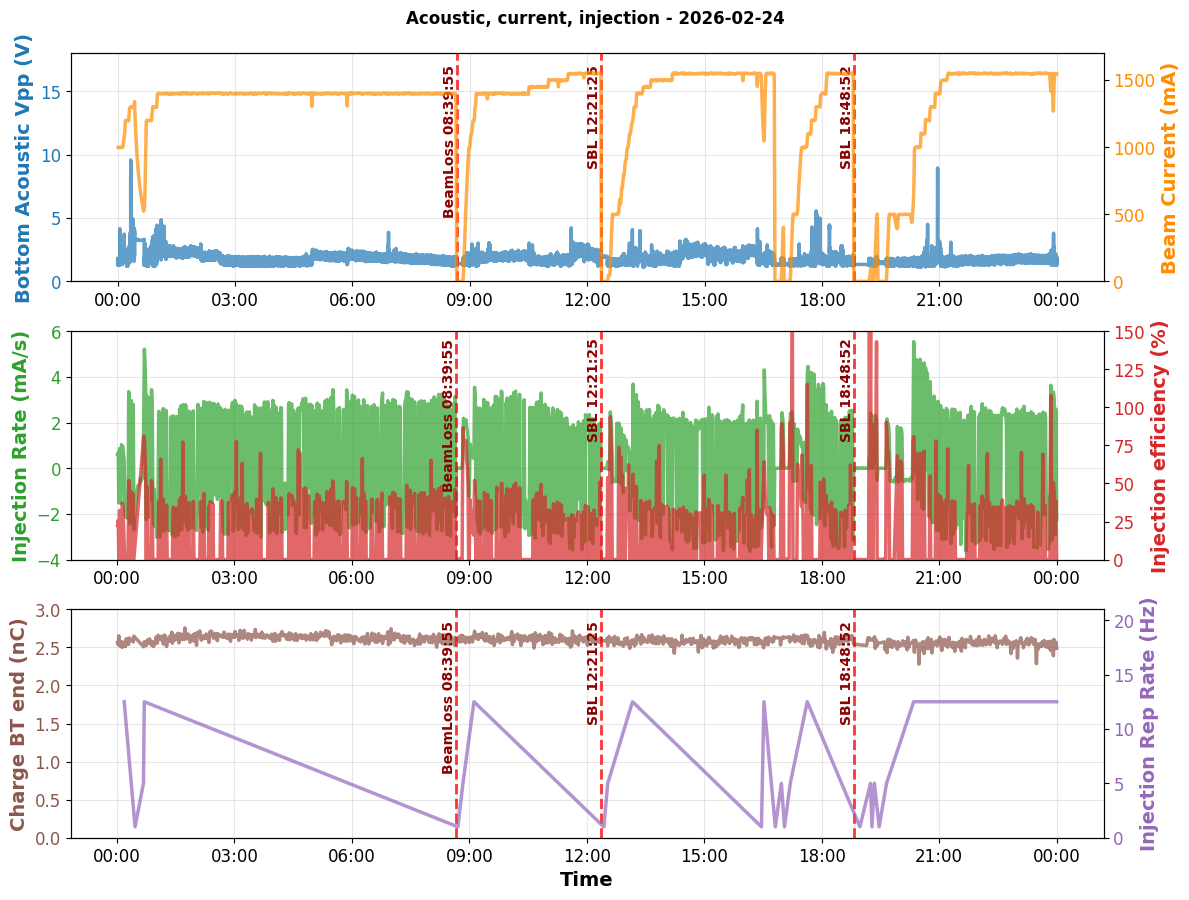


✓ Plotted 3-panel daily summary with abort events


In [55]:
# Plot machine variables in separate dual-axis figures (3 columns)
# Figure 1: Vpp + Beam Current
# Figure 2: Injection Rate + Injection Efficiency
# Figure 3: Charge + Injection Rep Rate
if filtered_df is not None and len(filtered_df) > 0 and machine_df_filtered is not None and len(machine_df_filtered) > 0:
    
    print(f"\n{'='*70}")
    print(f"Creating 3-panel daily plot")
    print(f"{'='*70}")
    
    # Create figure with 3 subplots in a row
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 9))
    
    # Add figure title with date
    date_formatted = datetime.strptime(date_str, "%Y%m%d").strftime("%Y-%m-%d")
    fig.suptitle(f'Acoustic, current, injection - {date_formatted}', fontsize=12, fontweight='bold', y=0.995)
    
    # ===== FIGURE 1: Vpp + Beam Current =====
    if 'A_BM_Current_mA' in machine_df_filtered.columns:
        # Get data
        mask_current = machine_df_filtered['A_BM_Current_mA'].notna()
        valid_times_current = machine_df_filtered.loc[mask_current, 'time_datetime']
        valid_current = machine_df_filtered.loc[mask_current, 'A_BM_Current_mA']
        
        # Plot Vpp on left y-axis
        color_vpp = 'tab:blue'
        ax1.set_ylabel('Bottom Acoustic Vpp (V)', color=color_vpp, fontsize=14, fontweight='bold')
        ax1.plot(filtered_df['time_datetime'], filtered_df['vpp_volts'], 
                linewidth=2.5, color=color_vpp, alpha=0.7, label='CH3 Vpp')
        ax1.tick_params(axis='y', labelcolor=color_vpp, labelsize=12)
        ax1.set_ylim(0, 18)
        ax1.grid(True, alpha=0.3)
        
        # Plot Beam Current on right y-axis
        ax1_right = ax1.twinx()
        color_current = 'darkorange'
        ax1_right.set_ylabel('Beam Current (mA)', color=color_current, fontsize=14, fontweight='bold')
        ax1_right.plot(valid_times_current, valid_current, 
                      linewidth=2.5, color=color_current, alpha=0.7, label=f'Beam Current ({len(valid_current)} pts)')
        ax1_right.tick_params(axis='y', labelcolor=color_current, labelsize=12)
        ax1_right.set_ylim(0, 1700)
        
        print(f"  ✓ Figure 1: Vpp ({len(filtered_df)} pts) + Beam Current ({len(valid_current)} pts)")
    
    # ===== FIGURE 2: Injection Rate + Injection Efficiency =====
    if 'A_BM_Inj_Rate_mAps' in machine_df_filtered.columns and 'A_INJ_Effi' in machine_df_filtered.columns:
        # Get Injection Rate
        mask_inj_rate = machine_df_filtered['A_BM_Inj_Rate_mAps'].notna()
        valid_times_inj_rate = machine_df_filtered.loc[mask_inj_rate, 'time_datetime']
        valid_inj_rate = machine_df_filtered.loc[mask_inj_rate, 'A_BM_Inj_Rate_mAps']
        
        # Get Injection Efficiency
        mask_effi = machine_df_filtered['A_INJ_Effi'].notna()
        valid_times_effi = machine_df_filtered.loc[mask_effi, 'time_datetime']
        valid_effi = machine_df_filtered.loc[mask_effi, 'A_INJ_Effi']
        
        # Plot Injection Rate on left y-axis
        color_inj_rate = 'tab:green'
        ax2.set_ylabel('Injection Rate (mA/s)', color=color_inj_rate, fontsize=14, fontweight='bold')
        ax2.plot(valid_times_inj_rate, valid_inj_rate, 
                linewidth=2.5, color=color_inj_rate, alpha=0.7, label=f'Inj Rate ({len(valid_inj_rate)} pts)')
        ax2.tick_params(axis='y', labelcolor=color_inj_rate, labelsize=12)
        ax2.set_ylim(-4, 6)
        ax2.grid(True, alpha=0.3)
        
        # Plot Injection Efficiency on right y-axis
        ax2_right = ax2.twinx()
        color_effi = 'tab:red'
        ax2_right.set_ylabel('Injection efficiency (%)', color=color_effi, fontsize=14, fontweight='bold')
        ax2_right.plot(valid_times_effi, valid_effi, 
                      linewidth=2.5, color=color_effi, alpha=0.7, label=f'Efficiency ({len(valid_effi)} pts)')
        ax2_right.tick_params(axis='y', labelcolor=color_effi, labelsize=12)
        ax2_right.set_ylim(0, 150)
        
        print(f"  ✓ Figure 2: Inj Rate ({len(valid_inj_rate)} pts) + Efficiency ({len(valid_effi)} pts)")
    
    # ===== FIGURE 3: Charge + Injection Rep Rate =====
    if 'A_Qep_BT_end_nC' in machine_df_filtered.columns and 'A_INJ_Rep_ep_Hz' in machine_df_filtered.columns:
        # Get Charge
        mask_charge = machine_df_filtered['A_Qep_BT_end_nC'].notna()
        valid_times_charge = machine_df_filtered.loc[mask_charge, 'time_datetime']
        valid_charge = machine_df_filtered.loc[mask_charge, 'A_Qep_BT_end_nC']
        
        # Get Rep Rate
        mask_rep = machine_df_filtered['A_INJ_Rep_ep_Hz'].notna()
        valid_times_rep = machine_df_filtered.loc[mask_rep, 'time_datetime']
        valid_rep = machine_df_filtered.loc[mask_rep, 'A_INJ_Rep_ep_Hz']
        
        # Plot Charge on left y-axis
        color_charge = 'tab:brown'
        ax3.set_ylabel('Charge BT end (nC)', color=color_charge, fontsize=14, fontweight='bold')
        ax3.plot(valid_times_charge, valid_charge, 
                linewidth=2.5, color=color_charge, alpha=0.7, label=f'Charge ({len(valid_charge)} pts)')
        ax3.tick_params(axis='y', labelcolor=color_charge, labelsize=12)
        ax3.set_ylim(0, 3)
        ax3.grid(True, alpha=0.3)
        
        # Plot Injection Rep Rate on right y-axis
        ax3_right = ax3.twinx()
        color_rep = 'tab:purple'
        ax3_right.set_ylabel('Injection Rep Rate (Hz)', color=color_rep, fontsize=14, fontweight='bold')
        ax3_right.plot(valid_times_rep, valid_rep, 
                      linewidth=2.5, color=color_rep, alpha=0.7, label=f'Rep Rate ({len(valid_rep)} pts)')
        ax3_right.tick_params(axis='y', labelcolor=color_rep, labelsize=12)
        ax3_right.set_ylim(0, 21)
        
        ax3.set_xlabel('Time', fontsize=14, fontweight='bold')
        print(f"  ✓ Figure 3: Charge ({len(valid_charge)} pts) + Rep Rate ({len(valid_rep)} pts)")
    
    # Mark abort events on all subplots
    if abort_today is not None and len(abort_today) > 0:
        print(f"\n  ✓ Marking {len(abort_today)} abort event(s) on all panels")
        for idx, row in abort_today.iterrows():
            abort_time = row['abort_datetime']
            # Check if abort time is within the data range
            if abort_time >= filtered_df['time_datetime'].min() and abort_time <= filtered_df['time_datetime'].max():
                # Determine color based on category
                if row['Category'] in ['SBL', 'BeamLoss']:
                    line_color = 'red'
                    text_color = 'darkred'
                else:
                    line_color = 'green'
                    text_color = 'darkgreen'
                
                # Mark on all three axes
                for ax in [ax1, ax2, ax3]:
                    ax.axvline(x=abort_time, color=line_color, linestyle='--', linewidth=2, alpha=0.8, zorder=10)
                    y_pos = ax.get_ylim()[1] * 0.95
                    label_text = f"{row['Category']} {abort_time.strftime('%H:%M:%S')}"
                    ax.text(abort_time, y_pos, label_text, 
                           rotation=90, verticalalignment='top', horizontalalignment='right',
                           fontsize=10, color=text_color, fontweight='bold', 
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.0, edgecolor=text_color))
    
    # Format x-axes
    for ax in [ax1, ax2, ax3]:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.tick_params(axis='x', labelsize=12)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"/Users/xylu/Desktop/Data/acoustic_vpp/daily_plots/{date_str}_machine_variables_panels.png", 
               dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Plotted 3-panel daily summary with abort events")
else:
    print("⚠ Missing required data for plots")

In [58]:
# AUTOMATIC BATCH PROCESSING: Generate daily plots with new 3-panel style for all dates
import re

print("="*80)
print("AUTOMATIC BATCH PROCESSING - Daily 3-Panel Machine Variables Plots")
print("="*80)

# Create output folder for plots
output_plot_folder = "/Users/xylu/Desktop/Data/acoustic_vpp/daily_plots"
os.makedirs(output_plot_folder, exist_ok=True)
print(f"\nOutput folder: {output_plot_folder}")

# Find all date folders in the acoustic_vpp directory
base_path = "/Users/xylu/Desktop/Data/acoustic_vpp/"
all_folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]

# Filter for folders that match YYYYMMDD format (8 digits)
date_pattern = re.compile(r'^\d{8}$')
date_folders = sorted([f for f in all_folders if date_pattern.match(f)])

print(f"\nFound {len(date_folders)} date folders to process:")
for df in date_folders:
    print(f"  - {df}")

# Load abort event data once
abort_data_path = "/Users/xylu/Desktop/Data/Complete_LER_Event_Data_Analysis_Summary.xlsx"
if os.path.exists(abort_data_path):
    abort_df_all = pd.read_excel(abort_data_path)
    abort_df_all['abort_datetime'] = pd.to_datetime(abort_df_all['Time'], format='%m/%d/%y %H:%M')
    print(f"\n✓ Loaded {len(abort_df_all)} total abort events from Excel")
else:
    print(f"\n⚠ Abort data file not found: {abort_data_path}")
    abort_df_all = None

print("\n" + "="*80)
print("Processing dates...")
print("="*80)

# Process each date
for date_str_auto in date_folders:
    print(f"\n[{date_str_auto}] Processing...")
    
    # Set up date objects for filtering
    date_obj_auto = datetime.strptime(date_str_auto, "%Y%m%d")
    start_time_obj_auto = datetime.strptime(date_str_auto + "000000", "%Y%m%d%H%M%S")
    end_time_obj_auto = datetime.strptime(date_str_auto + "235959", "%Y%m%d%H%M%S")
    
    # Load acoustic data for this date
    date_folder_auto = os.path.join(base_path, date_str_auto)
    csv_files_auto = sorted(glob.glob(os.path.join(date_folder_auto, f"{date_str_auto}*.csv")))
    
    if len(csv_files_auto) == 0:
        print(f"  ⚠ No acoustic CSV files found, skipping")
        continue
    
    # Load and combine acoustic CSV files for this date
    all_data_auto = []
    for csv_file in csv_files_auto:
        try:
            df_temp = pd.read_csv(csv_file)
            if 'time_datetime' in df_temp.columns:
                df_temp['time_datetime'] = pd.to_datetime(df_temp['time_datetime'], format='ISO8601')
            all_data_auto.append(df_temp)
        except Exception as e:
            print(f"  ✗ Error reading {os.path.basename(csv_file)}: {e}")
            continue
    
    if not all_data_auto:
        print(f"  ⚠ No acoustic data loaded, skipping")
        continue
    
    # Combine all acoustic data for this date
    combined_df_auto = pd.concat(all_data_auto, ignore_index=True)
    combined_df_auto = combined_df_auto.sort_values('time_datetime').reset_index(drop=True)
    
    # Filter by time range
    mask_auto = (combined_df_auto['time_datetime'] >= start_time_obj_auto) & (combined_df_auto['time_datetime'] <= end_time_obj_auto)
    filtered_df_auto = combined_df_auto[mask_auto].reset_index(drop=True)
    
    print(f"  ✓ Loaded {len(filtered_df_auto)} acoustic samples")
    
    # Load machine data from Machine subfolder
    machine_folder_auto = os.path.join(base_path, date_str_auto, "Machine")
    
    if not os.path.exists(machine_folder_auto):
        print(f"  ⚠ Machine folder not found, skipping")
        continue
    
    machine_csv_files_auto = sorted(glob.glob(os.path.join(machine_folder_auto, "*.csv")))
    
    if len(machine_csv_files_auto) == 0:
        print(f"  ⚠ No machine CSV files found, skipping")
        continue
    
    # Load and combine machine data files
    machine_data_list_auto = []
    for csv_file in machine_csv_files_auto:
        try:
            df_temp = pd.read_csv(csv_file)
            if 'Timestamp' in df_temp.columns:
                df_temp['Timestamp'] = pd.to_datetime(df_temp['Timestamp'], format='ISO8601')
            machine_data_list_auto.append(df_temp)
        except Exception as e:
            print(f"  ✗ Error reading {os.path.basename(csv_file)}: {e}")
            continue
    
    if not machine_data_list_auto:
        print(f"  ⚠ No machine data loaded, skipping")
        continue
    
    # Combine all machine data
    machine_df_auto = pd.concat(machine_data_list_auto, ignore_index=True)
    machine_df_auto = machine_df_auto.sort_values('Timestamp').reset_index(drop=True)
    
    # Rename Timestamp to time_datetime for consistency
    machine_df_auto.rename(columns={'Timestamp': 'time_datetime'}, inplace=True)
    
    # Rename columns to friendly names
    machine_df_auto.rename(columns=get_friendly_name, inplace=True)
    
    # Filter by time range
    mask_machine = (machine_df_auto['time_datetime'] >= start_time_obj_auto) & (machine_df_auto['time_datetime'] <= end_time_obj_auto)
    machine_df_filtered_auto = machine_df_auto[mask_machine].reset_index(drop=True)
    
    print(f"  ✓ Loaded {len(machine_df_filtered_auto)} machine data samples")
    
    # Filter abort events for this date
    if abort_df_all is not None:
        abort_date_start_auto = datetime.strptime(date_str_auto, "%Y%m%d").replace(hour=0, minute=0, second=0)
        abort_date_end_auto = abort_date_start_auto + timedelta(days=1)
        
        abort_mask_auto = (abort_df_all['abort_datetime'] >= abort_date_start_auto) & (abort_df_all['abort_datetime'] < abort_date_end_auto)
        abort_today_auto = abort_df_all[abort_mask_auto].copy()
        
        print(f"  ✓ Found {len(abort_today_auto)} abort event(s)")
    else:
        abort_today_auto = None
    
    # Create figure with 3 subplots
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 9))
    
    # Add figure title with date
    date_formatted_auto = datetime.strptime(date_str_auto, "%Y%m%d").strftime("%Y-%m-%d")
    fig.suptitle(f'Acoustic, current, injection - {date_formatted_auto}', fontsize=12, fontweight='bold', y=0.995)
    
    # ===== FIGURE 1: Vpp + Beam Current =====
    if 'A_BM_Current_mA' in machine_df_filtered_auto.columns:
        mask_current_auto = machine_df_filtered_auto['A_BM_Current_mA'].notna()
        valid_times_current_auto = machine_df_filtered_auto.loc[mask_current_auto, 'time_datetime']
        valid_current_auto = machine_df_filtered_auto.loc[mask_current_auto, 'A_BM_Current_mA']
        
        color_vpp = 'tab:blue'
        ax1.set_ylabel('Bottom Acoustic Vpp (V)', color=color_vpp, fontsize=14, fontweight='bold')
        ax1.plot(filtered_df_auto['time_datetime'], filtered_df_auto['vpp_volts'], 
                linewidth=2, color=color_vpp, alpha=0.7, label='CH3 Vpp')
        ax1.tick_params(axis='y', labelcolor=color_vpp, labelsize=12)
        ax1.set_ylim(0, 18)
        ax1.grid(True, alpha=0.3)
        
        ax1_right = ax1.twinx()
        color_current = 'darkorange'
        ax1_right.set_ylabel('Beam Current (mA)', color=color_current, fontsize=14, fontweight='bold')
        ax1_right.plot(valid_times_current_auto, valid_current_auto, 
                      linewidth=2, color=color_current, alpha=0.7, label=f'Beam Current ({len(valid_current_auto)} pts)')
        ax1_right.tick_params(axis='y', labelcolor=color_current, labelsize=12)
        ax1_right.set_ylim(0, 1700)
    
    # ===== FIGURE 2: Injection Rate + Injection Efficiency =====
    if 'A_BM_Inj_Rate_mAps' in machine_df_filtered_auto.columns and 'A_INJ_Effi' in machine_df_filtered_auto.columns:
        mask_inj_rate_auto = machine_df_filtered_auto['A_BM_Inj_Rate_mAps'].notna()
        valid_times_inj_rate_auto = machine_df_filtered_auto.loc[mask_inj_rate_auto, 'time_datetime']
        valid_inj_rate_auto = machine_df_filtered_auto.loc[mask_inj_rate_auto, 'A_BM_Inj_Rate_mAps']
        
        mask_effi_auto = machine_df_filtered_auto['A_INJ_Effi'].notna()
        valid_times_effi_auto = machine_df_filtered_auto.loc[mask_effi_auto, 'time_datetime']
        valid_effi_auto = machine_df_filtered_auto.loc[mask_effi_auto, 'A_INJ_Effi']
        
        color_inj_rate = 'tab:green'
        ax2.set_ylabel('Injection Rate (mA/s)', color=color_inj_rate, fontsize=14, fontweight='bold')
        ax2.plot(valid_times_inj_rate_auto, valid_inj_rate_auto, 
                linewidth=2, color=color_inj_rate, alpha=0.7, label=f'Inj Rate ({len(valid_inj_rate_auto)} pts)')
        ax2.tick_params(axis='y', labelcolor=color_inj_rate, labelsize=12)
        ax2.set_ylim(-4, 6)
        ax2.grid(True, alpha=0.3)
        
        ax2_right = ax2.twinx()
        color_effi = 'tab:red'
        ax2_right.set_ylabel('Injection efficiency (%)', color=color_effi, fontsize=14, fontweight='bold')
        ax2_right.plot(valid_times_effi_auto, valid_effi_auto, 
                      linewidth=2, color=color_effi, alpha=0.7, label=f'Efficiency ({len(valid_effi_auto)} pts)')
        ax2_right.tick_params(axis='y', labelcolor=color_effi, labelsize=12)
        ax2_right.set_ylim(0, 150)
    
    # ===== FIGURE 3: Charge + Injection Rep Rate =====
    if 'A_Qep_BT_end_nC' in machine_df_filtered_auto.columns and 'A_INJ_Rep_ep_Hz' in machine_df_filtered_auto.columns:
        mask_charge_auto = machine_df_filtered_auto['A_Qep_BT_end_nC'].notna()
        valid_times_charge_auto = machine_df_filtered_auto.loc[mask_charge_auto, 'time_datetime']
        valid_charge_auto = machine_df_filtered_auto.loc[mask_charge_auto, 'A_Qep_BT_end_nC']
        
        mask_rep_auto = machine_df_filtered_auto['A_INJ_Rep_ep_Hz'].notna()
        valid_times_rep_auto = machine_df_filtered_auto.loc[mask_rep_auto, 'time_datetime']
        valid_rep_auto = machine_df_filtered_auto.loc[mask_rep_auto, 'A_INJ_Rep_ep_Hz']
        
        color_charge = 'tab:brown'
        ax3.set_ylabel('Charge BT end (nC)', color=color_charge, fontsize=14, fontweight='bold')
        ax3.plot(valid_times_charge_auto, valid_charge_auto, 
                linewidth=2, color=color_charge, alpha=0.7, label=f'Charge ({len(valid_charge_auto)} pts)')
        ax3.tick_params(axis='y', labelcolor=color_charge, labelsize=12)
        ax3.set_ylim(0, 4)
        ax3.grid(True, alpha=0.3)
        
        ax3_right = ax3.twinx()
        color_rep = 'tab:purple'
        ax3_right.set_ylabel('Injection Rep Rate (Hz)', color=color_rep, fontsize=14, fontweight='bold')
        ax3_right.plot(valid_times_rep_auto, valid_rep_auto, 
                      linewidth=2, color=color_rep, alpha=0.7, label=f'Rep Rate ({len(valid_rep_auto)} pts)')
        ax3_right.tick_params(axis='y', labelcolor=color_rep, labelsize=12)
        ax3_right.set_ylim(0, 21)
        
        ax3.set_xlabel('Time', fontsize=14, fontweight='bold')
    
    # Mark abort events on all subplots
    if abort_today_auto is not None and len(abort_today_auto) > 0:
        for idx, row in abort_today_auto.iterrows():
            abort_time = row['abort_datetime']
            if abort_time >= filtered_df_auto['time_datetime'].min() and abort_time <= filtered_df_auto['time_datetime'].max():
                if row['Category'] in ['SBL', 'BeamLoss']:
                    line_color = 'red'
                    text_color = 'darkred'
                else:
                    line_color = 'green'
                    text_color = 'darkgreen'
                
                for ax in [ax1, ax2, ax3]:
                    ax.axvline(x=abort_time, color=line_color, linestyle='--', linewidth=2, alpha=0.8, zorder=10)
                    y_pos = ax.get_ylim()[1] * 0.95
                    label_text = f"{row['Category']} {abort_time.strftime('%H:%M:%S')}"
                    ax.text(abort_time, y_pos, label_text, 
                           rotation=90, verticalalignment='top', horizontalalignment='right',
                           fontsize=9, color=text_color,
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.0, edgecolor=text_color))
    
    # Format x-axes
    for ax in [ax1, ax2, ax3]:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.tick_params(axis='x', labelsize=12)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Save the figure
    plot_filename = f"{date_str_auto}_machine_variables_panels.png"
    plot_filepath = os.path.join(output_plot_folder, plot_filename)
    plt.savefig(plot_filepath, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"  ✓ Saved plot: {plot_filename}")

print("\n" + "="*80)
print("BATCH PROCESSING COMPLETE!")
print(f"All plots saved to: {output_plot_folder}")
print("="*80)

AUTOMATIC BATCH PROCESSING - Daily 3-Panel Machine Variables Plots

Output folder: /Users/xylu/Desktop/Data/acoustic_vpp/daily_plots

Found 30 date folders to process:
  - 20260126
  - 20260127
  - 20260128
  - 20260129
  - 20260130
  - 20260131
  - 20260201
  - 20260202
  - 20260203
  - 20260204
  - 20260205
  - 20260206
  - 20260207
  - 20260208
  - 20260209
  - 20260210
  - 20260211
  - 20260212
  - 20260213
  - 20260214
  - 20260215
  - 20260216
  - 20260217
  - 20260218
  - 20260219
  - 20260220
  - 20260221
  - 20260222
  - 20260223
  - 20260224

✓ Loaded 178 total abort events from Excel

Processing dates...

[20260126] Processing...
  ✓ Loaded 560576 acoustic samples
  ✓ Loaded 2256 machine data samples
  ✓ Found 18 abort event(s)
  ✓ Saved plot: 20260126_machine_variables_panels.png

[20260127] Processing...
  ✓ Loaded 1728493 acoustic samples
  ✓ Loaded 4049 machine data samples
  ✓ Found 16 abort event(s)
  ✓ Saved plot: 20260127_machine_variables_panels.png

[20260128] Proc

/var/folders/_c/0_qg_9695zvdpz5_56q4wy6w0000gn/T/ipykernel_48417/865323661.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df_auto = pd.concat(all_data_auto, ignore_index=True)


  ✓ Loaded 1458083 acoustic samples
  ✓ Loaded 4836 machine data samples
  ✓ Found 6 abort event(s)
  ✓ Saved plot: 20260202_machine_variables_panels.png

[20260203] Processing...
  ✓ Loaded 1728440 acoustic samples
  ✓ Loaded 4394 machine data samples
  ✓ Found 12 abort event(s)
  ✓ Saved plot: 20260203_machine_variables_panels.png

[20260204] Processing...
  ✓ Loaded 1728468 acoustic samples
  ✓ Loaded 4589 machine data samples
  ✓ Found 6 abort event(s)
  ✓ Saved plot: 20260204_machine_variables_panels.png

[20260205] Processing...
  ✓ Loaded 1728463 acoustic samples
  ✓ Loaded 4734 machine data samples
  ✓ Found 13 abort event(s)
  ✓ Saved plot: 20260205_machine_variables_panels.png

[20260206] Processing...
  ✓ Loaded 1728475 acoustic samples
  ✓ Loaded 4398 machine data samples
  ✓ Found 2 abort event(s)
  ✓ Saved plot: 20260206_machine_variables_panels.png

[20260207] Processing...
  ✓ Loaded 1728447 acoustic samples
  ✓ Loaded 4848 machine data samples
  ✓ Found 4 abort event(s

In [65]:
# CELL 1: Import libraries, load all data, and generate merged arrays

# Import libraries for correlation analysis
import numpy as np
from matplotlib.colors import TwoSlopeNorm

print("="*80)
print("CORRELATION ANALYSIS - STEP 1: Data Loading and Merging")
print("="*80)

# Parameters to correlate with acoustic signal
parameters_to_analyze = [
    'A_BM_Current_mA',
    'A_BM_Inj_Rate_mAps',
    'A_INJ_Effi',
    'A_INJ_Rep_ep_Hz',
    'A_Qep_BT_end_nC'
]

# Store merged data for each date
merged_data_by_date = {}

# Process each date
print(f"\nLoading and merging data from {len(date_folders)} dates...\n")

for date_str_corr in date_folders:
    # Load acoustic data
    date_folder_corr = os.path.join(base_path, date_str_corr)
    csv_files_corr = sorted(glob.glob(os.path.join(date_folder_corr, f"{date_str_corr}*.csv")))
    
    if len(csv_files_corr) == 0:
        continue
    
    # Load and combine acoustic data
    all_data_corr = []
    for csv_file in csv_files_corr:
        try:
            df_temp = pd.read_csv(csv_file)
            if 'time_datetime' in df_temp.columns:
                df_temp['time_datetime'] = pd.to_datetime(df_temp['time_datetime'], format='ISO8601')
            all_data_corr.append(df_temp)
        except:
            continue
    
    if not all_data_corr:
        continue
    
    acoustic_df_corr = pd.concat(all_data_corr, ignore_index=True)
    acoustic_df_corr = acoustic_df_corr.sort_values('time_datetime').reset_index(drop=True)
    
    # Load machine data
    machine_folder_corr = os.path.join(base_path, date_str_corr, "Machine")
    
    if not os.path.exists(machine_folder_corr):
        continue
    
    machine_csv_files_corr = sorted(glob.glob(os.path.join(machine_folder_corr, "*.csv")))
    
    if len(machine_csv_files_corr) == 0:
        continue
    
    # Load machine data
    machine_data_list_corr = []
    for csv_file in machine_csv_files_corr:
        try:
            df_temp = pd.read_csv(csv_file)
            if 'Timestamp' in df_temp.columns:
                df_temp['Timestamp'] = pd.to_datetime(df_temp['Timestamp'], format='ISO8601')
            machine_data_list_corr.append(df_temp)
        except:
            continue
    
    if not machine_data_list_corr:
        continue
    
    machine_df_corr = pd.concat(machine_data_list_corr, ignore_index=True)
    machine_df_corr = machine_df_corr.sort_values('Timestamp').reset_index(drop=True)
    machine_df_corr.rename(columns={'Timestamp': 'time_datetime'}, inplace=True)
    machine_df_corr.rename(columns=get_friendly_name, inplace=True)
    
    # Merge acoustic and machine data on time_datetime
    merged_df = pd.merge_asof(
        acoustic_df_corr.sort_values('time_datetime'),
        machine_df_corr.sort_values('time_datetime'),
        on='time_datetime',
        direction='nearest',
        tolerance=pd.Timedelta('10s')
    )
    
    # Store merged data for this date
    merged_data_by_date[date_str_corr] = merged_df
    
    print(f"[{date_str_corr}] Loaded and merged {len(merged_df)} data points")

# Combine all data into a single dataframe
print(f"\nCombining data from all dates...")
all_merged_df = pd.concat(merged_data_by_date.values(), ignore_index=True)
print(f"Total combined data points: {len(all_merged_df)}")
print(f"\n✓ Data loading complete! Stored {len(merged_data_by_date)} dates.")

CORRELATION ANALYSIS - STEP 1: Data Loading and Merging

Loading and merging data from 30 dates...

[20260126] Loaded and merged 560595 data points
[20260127] Loaded and merged 1728512 data points
[20260128] Loaded and merged 1728489 data points
[20260129] Loaded and merged 1728480 data points
[20260130] Loaded and merged 1728484 data points
[20260131] Loaded and merged 1728486 data points
[20260201] Loaded and merged 1728463 data points


/var/folders/_c/0_qg_9695zvdpz5_56q4wy6w0000gn/T/ipykernel_48417/3261168281.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  acoustic_df_corr = pd.concat(all_data_corr, ignore_index=True)


[20260202] Loaded and merged 1458083 data points
[20260203] Loaded and merged 1728459 data points
[20260204] Loaded and merged 1728487 data points
[20260205] Loaded and merged 1728482 data points
[20260206] Loaded and merged 1728494 data points
[20260207] Loaded and merged 1728466 data points
[20260208] Loaded and merged 1728502 data points
[20260209] Loaded and merged 1728448 data points
[20260210] Loaded and merged 1728468 data points
[20260211] Loaded and merged 1728473 data points
[20260212] Loaded and merged 1728505 data points
[20260213] Loaded and merged 1728484 data points
[20260214] Loaded and merged 1728468 data points
[20260215] Loaded and merged 855749 data points
[20260216] Loaded and merged 1031992 data points
[20260217] Loaded and merged 806371 data points
[20260218] Loaded and merged 1231610 data points
[20260219] Loaded and merged 1728477 data points
[20260220] Loaded and merged 1728465 data points
[20260221] Loaded and merged 1728482 data points
[20260222] Loaded and 


CORRELATION ANALYSIS - STEP 2: Calculations and Visualization

Calculating Injection Loss Rate...
  ✓ Calculated Inj_Loss_Rate for combined data (handling zero efficiency)

Calculating daily correlations...


/Users/xylu/Desktop/Data/code/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/xylu/Desktop/Data/code/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  ✓ Calculated correlations for 30 dates

Calculating overall correlations...
  ✓ Calculated 6 overall correlations

OVERALL CORRELATIONS (All Dates Combined)
Parameter                          Correlation        Strength
--------------------------------------------------------------------------------
Injection Loss Rate                     0.5713        Moderate
Beam Current                            0.5540        Moderate
Injection Rep Rate                      0.4790        Moderate
Injection Efficiency                   -0.1995       Very Weak
Injection Rate                         -0.0894       Very Weak
Charge BT End                          -0.0265       Very Weak

GENERATING VISUALIZATIONS


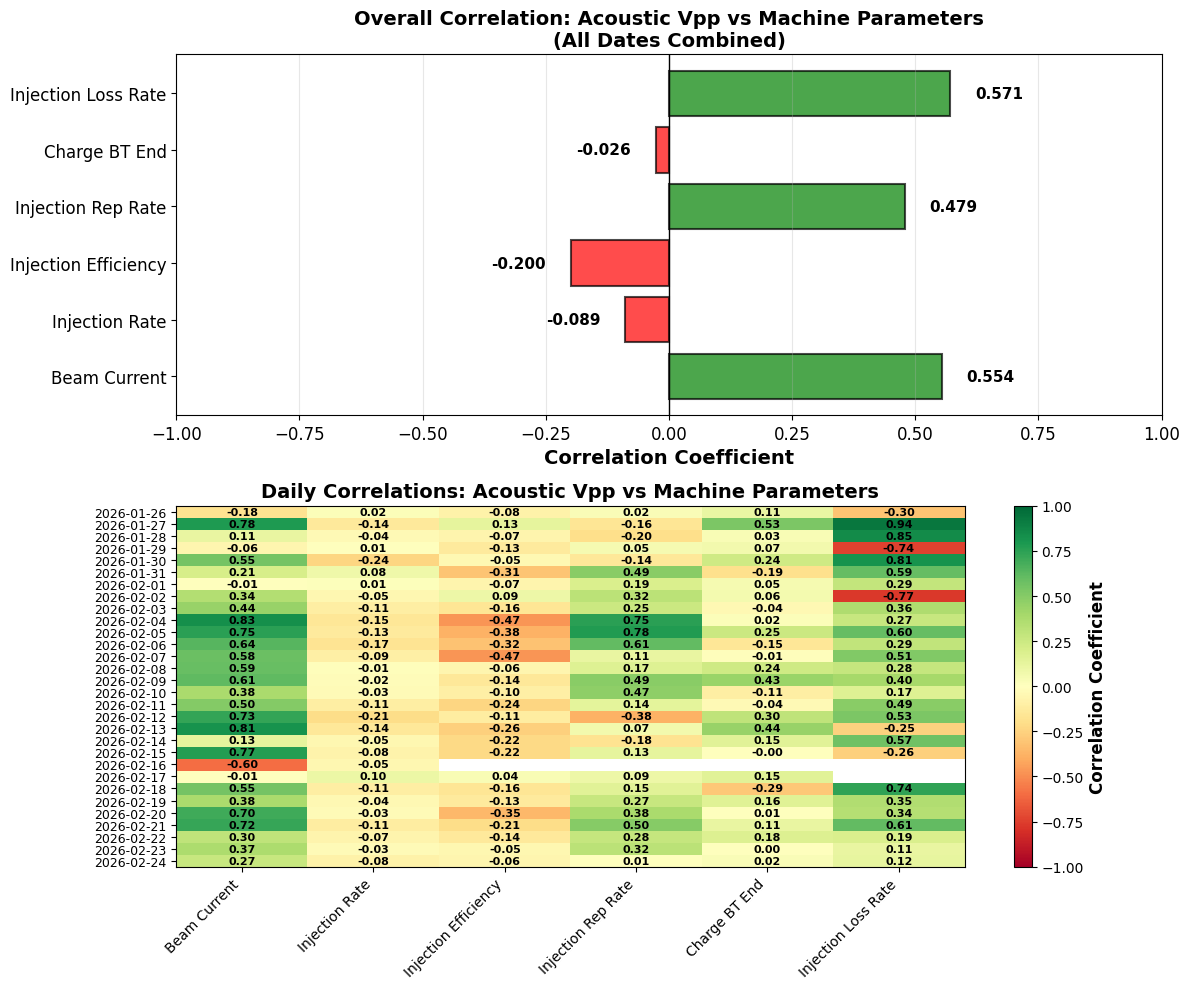


✓ Correlation analysis complete!
✓ Saved: correlation_analysis.png


In [67]:
# CELL 2: Calculate loss rate, calculate correlations, and plot

print("\n" + "="*80)
print("CORRELATION ANALYSIS - STEP 2: Calculations and Visualization")
print("="*80)

# Calculate derived parameter: Injection Loss Rate = (1-Efficiency)/Efficiency * Injection Rate
print("\nCalculating Injection Loss Rate...")

# Calculate for combined dataframe
if 'A_INJ_Effi' in all_merged_df.columns and 'A_BM_Inj_Rate_mAps' in all_merged_df.columns:
    effi_fraction = all_merged_df['A_INJ_Effi'] / 100.0
    # Set NaN for zero efficiency to avoid division by zero
    all_merged_df['Inj_Loss_Rate'] = np.where(
        effi_fraction != 0,
        (1 - effi_fraction) / effi_fraction * all_merged_df['A_BM_Inj_Rate_mAps'],
        np.nan
    )
    print(f"  ✓ Calculated Inj_Loss_Rate for combined data (handling zero efficiency)")

# Calculate for each date's merged data
for date_str, merged_df in merged_data_by_date.items():
    if 'A_INJ_Effi' in merged_df.columns and 'A_BM_Inj_Rate_mAps' in merged_df.columns:
        effi_fraction = merged_df['A_INJ_Effi'] / 100.0
        # Set NaN for zero efficiency to avoid division by zero
        merged_df['Inj_Loss_Rate'] = np.where(
            effi_fraction != 0,
            (1 - effi_fraction) / effi_fraction * merged_df['A_BM_Inj_Rate_mAps'],
            np.nan
        )

# Calculate daily correlations
print("\nCalculating daily correlations...")
daily_correlations = {}

for date_str, merged_df in merged_data_by_date.items():
    date_corr = {}
    
    for param in parameters_to_analyze:
        if param in merged_df.columns:
            valid_mask = merged_df['vpp_volts'].notna() & merged_df[param].notna()
            if valid_mask.sum() > 10:  # Need at least 10 points
                corr = merged_df.loc[valid_mask, 'vpp_volts'].corr(merged_df.loc[valid_mask, param])
                date_corr[param] = corr
    
    # Correlation with derived parameter
    if 'Inj_Loss_Rate' in merged_df.columns:
        valid_mask = merged_df['vpp_volts'].notna() & merged_df['Inj_Loss_Rate'].notna()
        if valid_mask.sum() > 10:
            corr = merged_df.loc[valid_mask, 'vpp_volts'].corr(merged_df.loc[valid_mask, 'Inj_Loss_Rate'])
            date_corr['Inj_Loss_Rate'] = corr
    
    daily_correlations[date_str] = date_corr

print(f"  ✓ Calculated correlations for {len(daily_correlations)} dates")

# Calculate overall correlations (all dates combined)
print("\nCalculating overall correlations...")
overall_corr = {}

for param in parameters_to_analyze:
    if param in all_merged_df.columns:
        valid_mask = all_merged_df['vpp_volts'].notna() & all_merged_df[param].notna()
        if valid_mask.sum() > 10:
            corr = all_merged_df.loc[valid_mask, 'vpp_volts'].corr(all_merged_df.loc[valid_mask, param])
            overall_corr[param] = corr

# Overall correlation with derived parameter
if 'Inj_Loss_Rate' in all_merged_df.columns:
    valid_mask = all_merged_df['vpp_volts'].notna() & all_merged_df['Inj_Loss_Rate'].notna()
    if valid_mask.sum() > 10:
        corr = all_merged_df.loc[valid_mask, 'vpp_volts'].corr(all_merged_df.loc[valid_mask, 'Inj_Loss_Rate'])
        overall_corr['Inj_Loss_Rate'] = corr

print(f"  ✓ Calculated {len(overall_corr)} overall correlations")

# Print overall correlations
print("\n" + "="*80)
print("OVERALL CORRELATIONS (All Dates Combined)")
print("="*80)
print(f"{'Parameter':<30} {'Correlation':>15} {'Strength':>15}")
print("-"*80)

# Helper function to classify correlation strength
def corr_strength(r):
    abs_r = abs(r)
    if abs_r >= 0.7:
        return "Strong"
    elif abs_r >= 0.4:
        return "Moderate"
    elif abs_r >= 0.2:
        return "Weak"
    else:
        return "Very Weak"

# Friendly names for display
param_names = {
    'A_BM_Current_mA': 'Beam Current',
    'A_BM_Inj_Rate_mAps': 'Injection Rate',
    'A_INJ_Effi': 'Injection Efficiency',
    'A_INJ_Rep_ep_Hz': 'Injection Rep Rate',
    'A_Qep_BT_end_nC': 'Charge BT End',
    'Inj_Loss_Rate': 'Injection Loss Rate'
}

for param, corr in sorted(overall_corr.items(), key=lambda x: abs(x[1]), reverse=True):
    name = param_names.get(param, param)
    print(f"{name:<30} {corr:>15.4f} {corr_strength(corr):>15}")

# Create visualization
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# Figure 1: Overall correlations bar chart + Daily correlations heatmap
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Overall correlations
params_display = [param_names.get(p, p) for p in overall_corr.keys()]
corr_values = list(overall_corr.values())
colors = ['red' if c < 0 else 'green' for c in corr_values]

bars = ax1.barh(params_display, corr_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax1.set_xlabel('Correlation Coefficient', fontsize=14, fontweight='bold')
ax1.set_title('Overall Correlation: Acoustic Vpp vs Machine Parameters\n(All Dates Combined)', 
              fontsize=14, fontweight='bold')
ax1.set_xlim(-1, 1)
ax1.grid(True, alpha=0.3, axis='x')
ax1.tick_params(labelsize=12)

# Add correlation values on bars
for i, (bar, val) in enumerate(zip(bars, corr_values)):
    x_pos = val + (0.05 if val > 0 else -0.05)
    ax1.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            ha='left' if val > 0 else 'right', va='center', fontsize=11, fontweight='bold')

# Plot 2: Daily correlations heatmap
# Convert daily correlations to DataFrame for easier plotting
daily_corr_df = pd.DataFrame(daily_correlations).T
daily_corr_df.rename(columns=param_names, inplace=True)
daily_corr_df.index = [datetime.strptime(d, '%Y%m%d').strftime('%Y-%m-%d') for d in daily_corr_df.index]

# Plot heatmap
im = ax2.imshow(daily_corr_df.values, cmap='RdYlGn', aspect='auto', 
                norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1))

# Set ticks and labels
ax2.set_xticks(np.arange(len(daily_corr_df.columns)))
ax2.set_yticks(np.arange(len(daily_corr_df.index)))
ax2.set_xticklabels(daily_corr_df.columns, rotation=45, ha='right', fontsize=10)
ax2.set_yticklabels(daily_corr_df.index, fontsize=9)
ax2.set_title('Daily Correlations: Acoustic Vpp vs Machine Parameters', 
              fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Correlation Coefficient', fontsize=12, fontweight='bold')

# Add text annotations
for i in range(len(daily_corr_df.index)):
    for j in range(len(daily_corr_df.columns)):
        val = daily_corr_df.iloc[i, j]
        if pd.notna(val):
            text = ax2.text(j, i, f'{val:.2f}',
                          ha="center", va="center", color="black", fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/xylu/Desktop/Data/acoustic_vpp/daily_plots/correlation_analysis.png', 
           dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Correlation analysis complete!")
print(f"✓ Saved: correlation_analysis.png")

SCATTER PLOT ANALYSIS
  ✓ Scatter plot 1/6: Injection Loss Rate (r=0.571, n=5000)
  ✓ Scatter plot 2/6: Beam Current (r=0.554, n=5000)
  ✓ Scatter plot 3/6: Injection Rep Rate (r=0.479, n=5000)
  ✓ Scatter plot 4/6: Injection Efficiency (r=-0.200, n=5000)
  ✓ Scatter plot 5/6: Injection Rate (r=-0.089, n=5000)
  ✓ Scatter plot 6/6: Charge BT End (r=-0.026, n=5000)


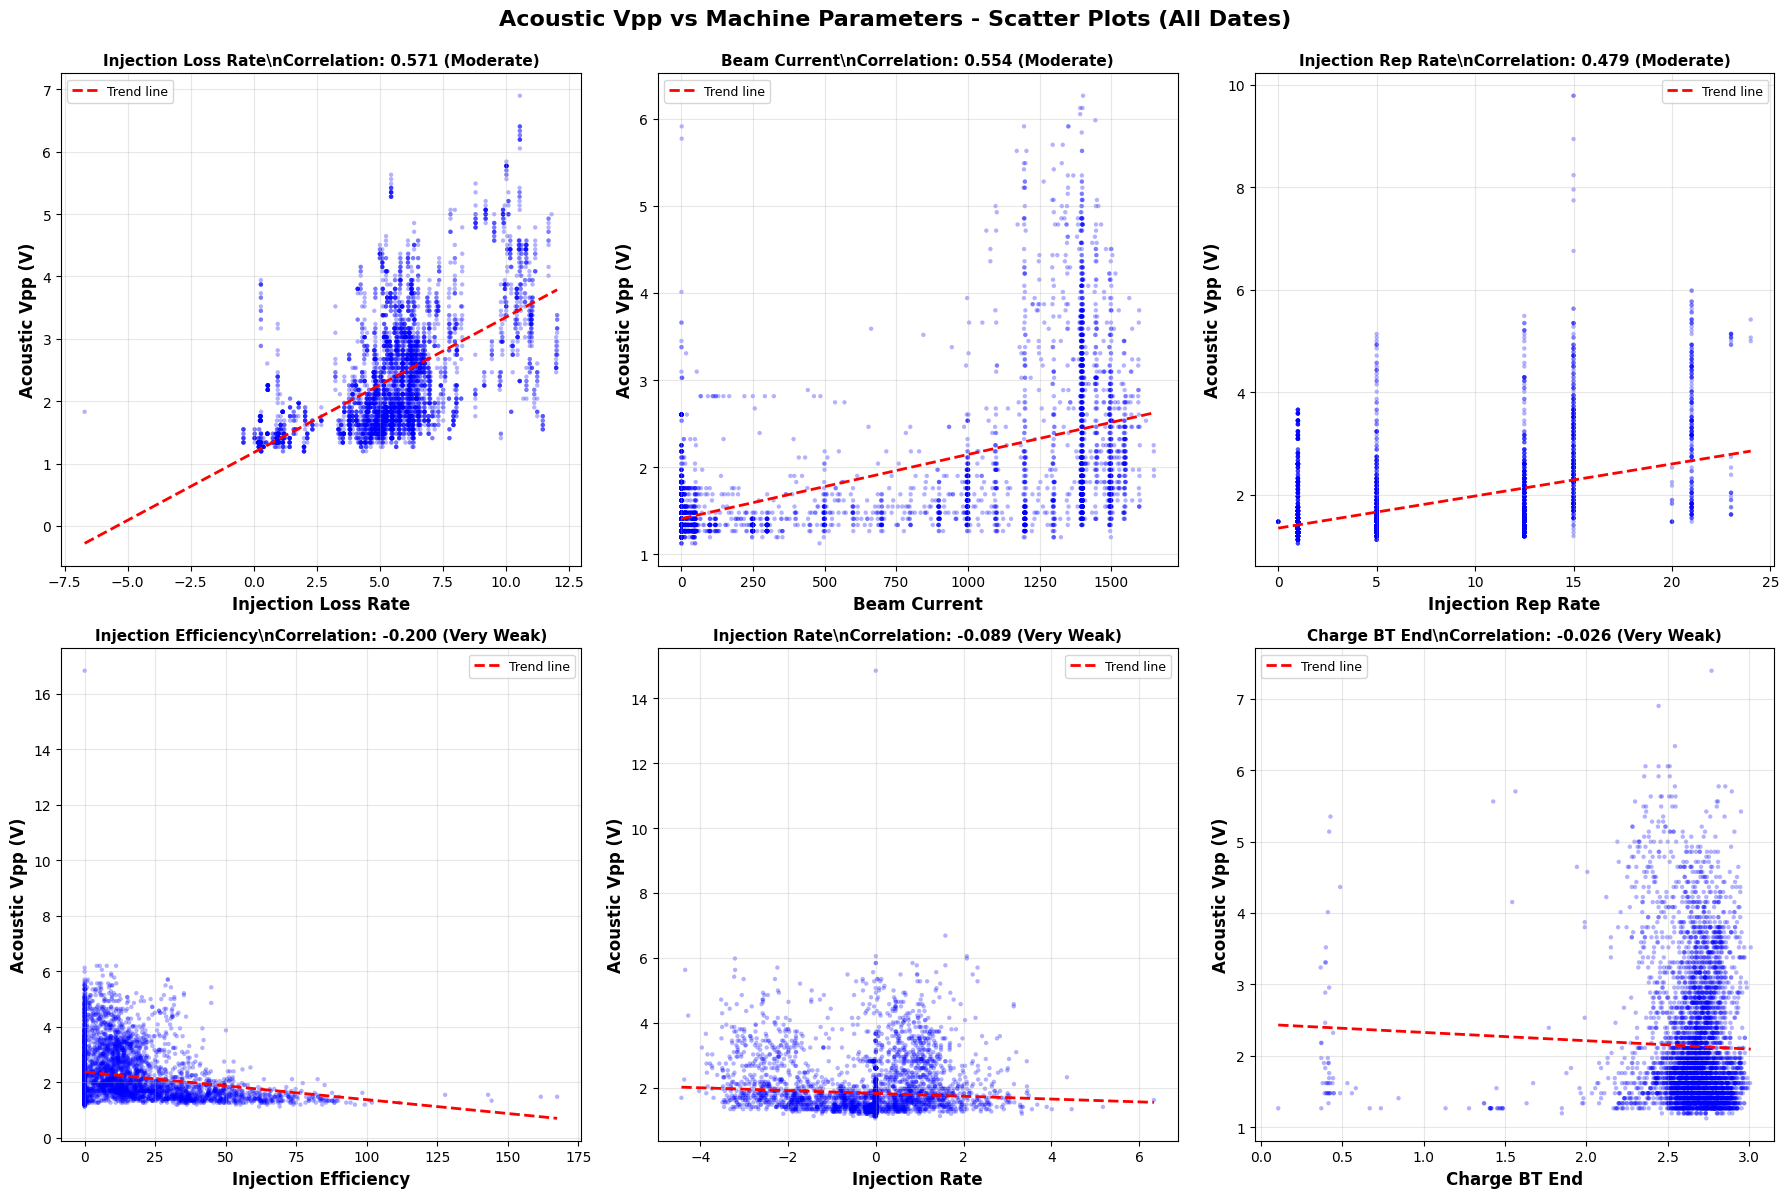

\n✓ Scatter plot analysis complete!
✓ Saved: correlation_scatter_plots.png


In [68]:
# SCATTER PLOTS: Visualize relationships between Acoustic Vpp and Machine Parameters

print("="*80)
print("SCATTER PLOT ANALYSIS")
print("="*80)

# Select top parameters by absolute correlation
top_params = sorted(overall_corr.items(), key=lambda x: abs(x[1]), reverse=True)

# Create scatter plots for top correlated parameters
n_plots = min(6, len(top_params))  # Show up to 6 scatter plots

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx in range(n_plots):
    param, corr = top_params[idx]
    ax = axes[idx]
    
    # Get valid data points
    valid_mask = all_merged_df['vpp_volts'].notna() & all_merged_df[param].notna()
    x_data = all_merged_df.loc[valid_mask, param]
    y_data = all_merged_df.loc[valid_mask, 'vpp_volts']
    
    # Sample data if too many points (for faster plotting)
    if len(x_data) > 5000:
        sample_indices = np.random.choice(len(x_data), 5000, replace=False)
        x_data = x_data.iloc[sample_indices]
        y_data = y_data.iloc[sample_indices]
    
    # Create scatter plot
    ax.scatter(x_data, y_data, alpha=0.3, s=10, c='blue', edgecolors='none')
    
    # Add trend line
    z = np.polyfit(x_data, y_data, 1)
    p = np.poly1d(z)
    x_trend = np.linspace(x_data.min(), x_data.max(), 100)
    ax.plot(x_trend, p(x_trend), "r--", linewidth=2, label=f'Trend line')
    
    # Labels and title
    param_display = param_names.get(param, param)
    ax.set_xlabel(param_display, fontsize=12, fontweight='bold')
    ax.set_ylabel('Acoustic Vpp (V)', fontsize=12, fontweight='bold')
    ax.set_title(f'{param_display}\\nCorrelation: {corr:.3f} ({corr_strength(corr)})', 
                fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=9)
    
    print(f"  ✓ Scatter plot {idx+1}/{n_plots}: {param_display} (r={corr:.3f}, n={len(x_data)})")

# Hide unused subplots
for idx in range(n_plots, 6):
    axes[idx].axis('off')

plt.suptitle('Acoustic Vpp vs Machine Parameters - Scatter Plots (All Dates)', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('/Users/xylu/Desktop/Data/acoustic_vpp/daily_plots/correlation_scatter_plots.png', 
           dpi=150, bbox_inches='tight')
plt.show()

print("\\n✓ Scatter plot analysis complete!")
print(f"✓ Saved: correlation_scatter_plots.png")

CORRELATION ANALYSIS - FILTERED BY BEAM CURRENT RANGE


Beam Current Filter: Current >= 1000 mA

Original data points: 47427913
Filtered data points: 2623940
Percentage retained: 5.5%

CORRELATION ANALYSIS - FILTERED CALCULATIONS (Current >= 1000 mA)

Calculating overall correlations for filtered data...
  ✓ Calculated 6 correlations

FILTERED OVERALL CORRELATIONS (Current >= 1000 mA)
Parameter                          Correlation        Strength
--------------------------------------------------------------------------------
Injection Loss Rate                     0.5435        Moderate
Injection Rep Rate                      0.4882        Moderate
Injection Efficiency                   -0.3615            Weak
Charge BT End                          -0.3585            Weak
Beam Current                            0.0710       Very Weak
Injection Rate                          0.0148       Very Weak

COMPARISON: Unfiltered vs Filtered
Parameter                           Unfiltered        

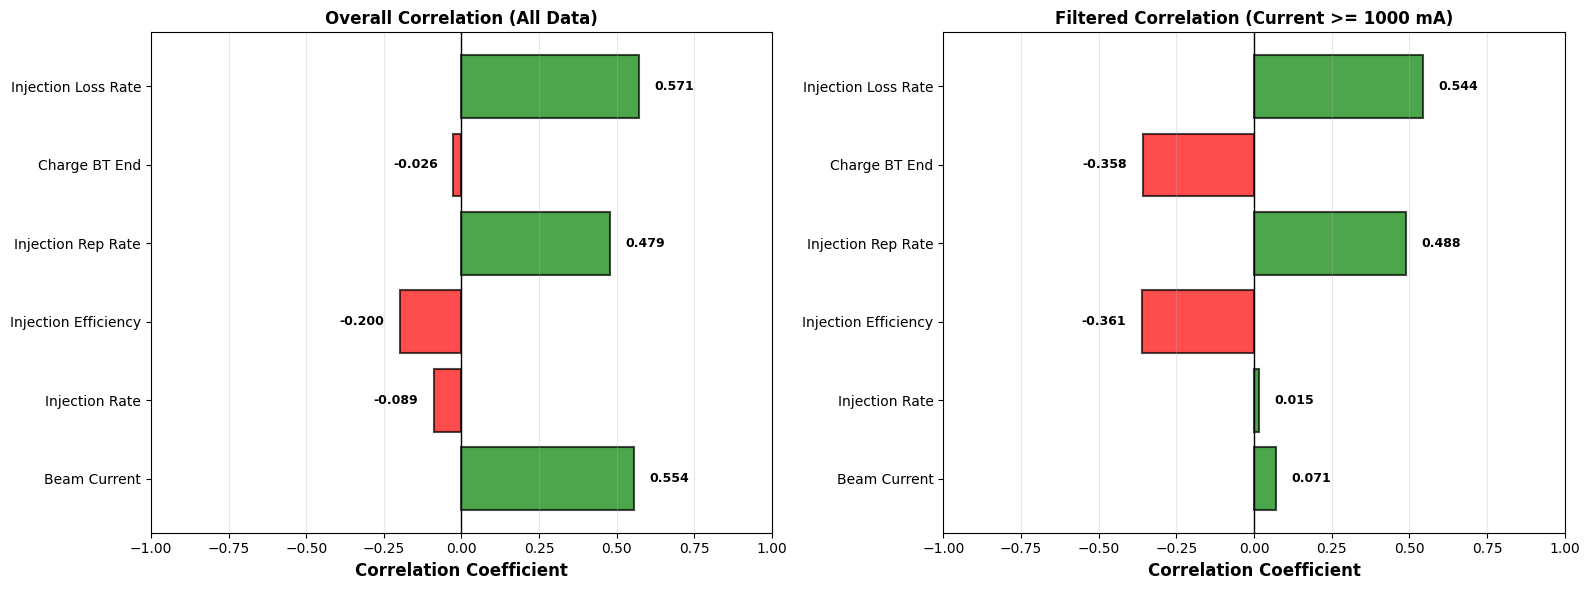


✓ Filtered correlation analysis complete!
✓ Saved: correlation_filtered_comparison.png


In [71]:
# Correlation factors with filtered data with beam current range

print("="*80)
print("CORRELATION ANALYSIS - FILTERED BY BEAM CURRENT RANGE")
print("="*80)

# User-defined current range
current_lower = 1000  # Lower limit in mA (None to use all)
current_upper = None   # Upper limit in mA (None to use all)

# Format filter description
if current_lower is None and current_upper is None:
    current_desc = "All data (no filter)"
elif current_lower is None:
    current_desc = f"Current <= {current_upper} mA"
elif current_upper is None:
    current_desc = f"Current >= {current_lower} mA"
else:
    current_desc = f"{current_lower} <= Current <= {current_upper} mA"

print(f"\n\nBeam Current Filter: {current_desc}")

# Create filtered dataframe based on current range
if 'A_BM_Current_mA' in all_merged_df.columns:
    # Start with all data
    filtered_by_current_df = all_merged_df.copy()
    
    # Apply lower limit
    if current_lower is not None:
        filtered_by_current_df = filtered_by_current_df[filtered_by_current_df['A_BM_Current_mA'] >= current_lower]
    
    # Apply upper limit
    if current_upper is not None:
        filtered_by_current_df = filtered_by_current_df[filtered_by_current_df['A_BM_Current_mA'] <= current_upper]
    
    print(f"\nOriginal data points: {len(all_merged_df)}")
    print(f"Filtered data points: {len(filtered_by_current_df)}")
    print(f"Percentage retained: {100.0 * len(filtered_by_current_df) / len(all_merged_df):.1f}%")
else:
    print("⚠ Beam current column not found!")
    filtered_by_current_df = all_merged_df.copy()

print("\n" + "="*80)
print(f"CORRELATION ANALYSIS - FILTERED CALCULATIONS ({current_desc})")
print("="*80)

# Calculate overall correlations for filtered data
print("\nCalculating overall correlations for filtered data...")
overall_corr_filtered = {}

for param in parameters_to_analyze:
    if param in filtered_by_current_df.columns:
        valid_mask = filtered_by_current_df['vpp_volts'].notna() & filtered_by_current_df[param].notna()
        if valid_mask.sum() > 10:
            corr = filtered_by_current_df.loc[valid_mask, 'vpp_volts'].corr(filtered_by_current_df.loc[valid_mask, param])
            overall_corr_filtered[param] = corr

# Overall correlation with derived parameter
if 'Inj_Loss_Rate' in filtered_by_current_df.columns:
    valid_mask = filtered_by_current_df['vpp_volts'].notna() & filtered_by_current_df['Inj_Loss_Rate'].notna()
    if valid_mask.sum() > 10:
        corr = filtered_by_current_df.loc[valid_mask, 'vpp_volts'].corr(filtered_by_current_df.loc[valid_mask, 'Inj_Loss_Rate'])
        overall_corr_filtered['Inj_Loss_Rate'] = corr

print(f"  ✓ Calculated {len(overall_corr_filtered)} correlations")

# Print overall correlations
print("\n" + "="*80)
print(f"FILTERED OVERALL CORRELATIONS ({current_desc})")
print("="*80)
print(f"{'Parameter':<30} {'Correlation':>15} {'Strength':>15}")
print("-"*80)

for param, corr in sorted(overall_corr_filtered.items(), key=lambda x: abs(x[1]), reverse=True):
    name = param_names.get(param, param)
    print(f"{name:<30} {corr:>15.4f} {corr_strength(corr):>15}")

# Compare with unfiltered correlations
print("\n" + "="*80)
print("COMPARISON: Unfiltered vs Filtered")
print("="*80)
print(f"{'Parameter':<30} {'Unfiltered':>15} {'Filtered':>15} {'Diff':>15}")
print("-"*80)

for param in sorted(overall_corr.keys()):
    unfiltered = overall_corr.get(param, np.nan)
    filtered = overall_corr_filtered.get(param, np.nan)
    if pd.notna(unfiltered) and pd.notna(filtered):
        diff = filtered - unfiltered
        name = param_names.get(param, param)
        print(f"{name:<30} {unfiltered:>15.4f} {filtered:>15.4f} {diff:>15.4f}")

# Create visualization comparing both
print("\n" + "="*80)
print("GENERATING FILTERED VISUALIZATIONS")
print("="*80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Unfiltered correlations
params_display_all = [param_names.get(p, p) for p in overall_corr.keys()]
corr_values_all = list(overall_corr.values())
colors_all = ['red' if c < 0 else 'green' for c in corr_values_all]

bars1 = ax1.barh(params_display_all, corr_values_all, color=colors_all, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax1.set_xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax1.set_title('Overall Correlation (All Data)', fontsize=12, fontweight='bold')
ax1.set_xlim(-1, 1)
ax1.grid(True, alpha=0.3, axis='x')
ax1.tick_params(labelsize=10)

# Add values on bars
for bar, val in zip(bars1, corr_values_all):
    x_pos = val + (0.05 if val > 0 else -0.05)
    ax1.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            ha='left' if val > 0 else 'right', va='center', fontsize=9, fontweight='bold')

# Plot 2: Filtered correlations
params_display_filt = [param_names.get(p, p) for p in overall_corr_filtered.keys()]
corr_values_filt = list(overall_corr_filtered.values())
colors_filt = ['red' if c < 0 else 'green' for c in corr_values_filt]

bars2 = ax2.barh(params_display_filt, corr_values_filt, color=colors_filt, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax2.set_title(f'Filtered Correlation ({current_desc})', fontsize=12, fontweight='bold')
ax2.set_xlim(-1, 1)
ax2.grid(True, alpha=0.3, axis='x')
ax2.tick_params(labelsize=10)

# Add values on bars
for bar, val in zip(bars2, corr_values_filt):
    x_pos = val + (0.05 if val > 0 else -0.05)
    ax2.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            ha='left' if val > 0 else 'right', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/xylu/Desktop/Data/acoustic_vpp/daily_plots/correlation_filtered_comparison.png', 
           dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Filtered correlation analysis complete!")
print(f"✓ Saved: correlation_filtered_comparison.png")

CORRELATION COMPARISON - 4 BEAM CURRENT SCENARIOS

[All Data] Data points: 47427913

[Current > 1000 mA] Data points: 2623940

[Current > 1100 mA] Data points: 2468146

[Current > 1200 mA] Data points: 2174236

SUMMARY TABLE - Correlations Across 4 Cases
Parameter                      All Data        Current > 1000 mA Current > 1100 mA Current > 1200 mA
----------------------------------------------------------------------------------------------------
Beam Current                           0.5540         0.0710        -0.0261        -0.1686
Injection Rate                        -0.0894         0.0148         0.0214         0.0261
Injection Efficiency                  -0.1995        -0.3615        -0.4060        -0.4553
Injection Rep Rate                     0.4790         0.4882         0.4882         0.4882
Charge BT End                         -0.0265        -0.3585        -0.3585        -0.0757
Injection Loss Rate                    0.5713         0.5435         0.5443         0.58

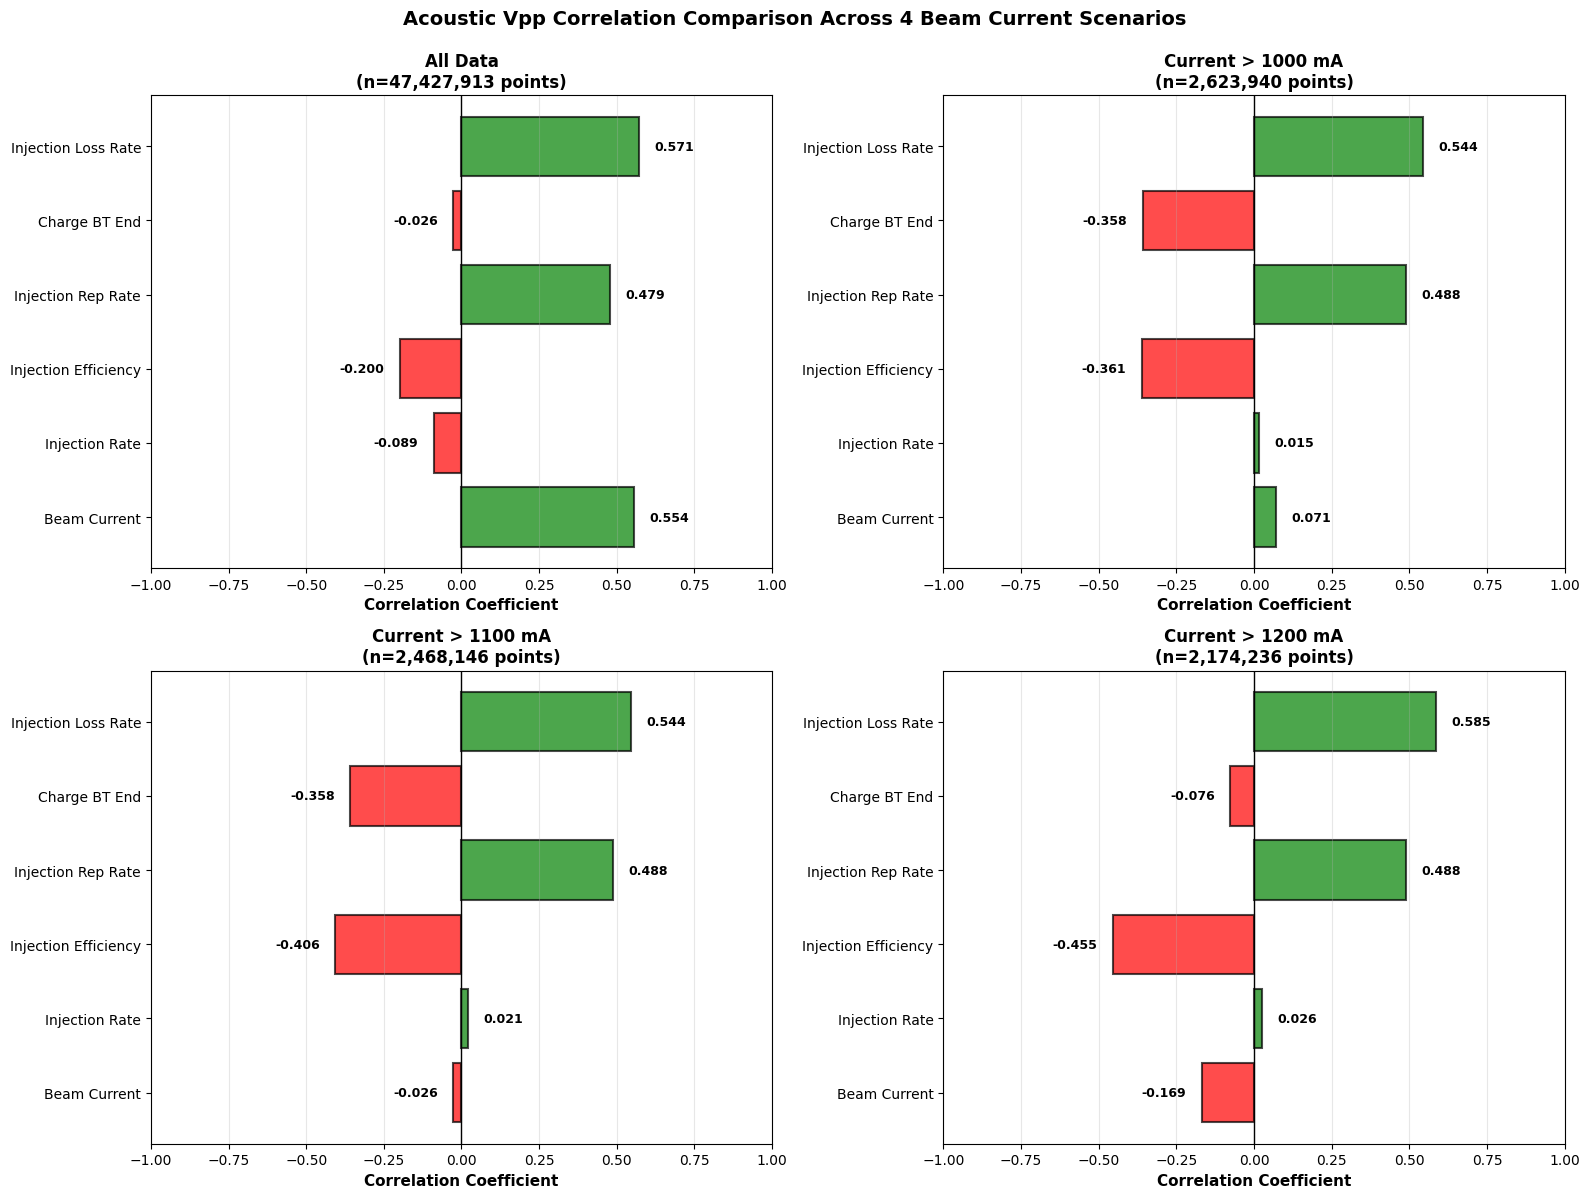


✓ 4-case comparison complete!
✓ Saved: correlation_4case_comparison.png


In [72]:
# CELL 5: Multi-case comparison - 4 different current thresholds

print("="*80)
print("CORRELATION COMPARISON - 4 BEAM CURRENT SCENARIOS")
print("="*80)

# Define 4 cases to compare
cases = [
    {'lower': None, 'upper': None, 'label': 'All Data'},
    {'lower': 1000, 'upper': None, 'label': 'Current > 1000 mA'},
    {'lower': 1100, 'upper': None, 'label': 'Current > 1100 mA'},
    {'lower': 1200, 'upper': None, 'label': 'Current > 1200 mA'},
]

# Calculate correlations for each case
case_correlations = {}
case_data_counts = {}

for case in cases:
    case_label = case['label']
    lower = case['lower']
    upper = case['upper']
    
    # Filter data based on current range
    filtered_df = all_merged_df.copy()
    
    if lower is not None:
        filtered_df = filtered_df[filtered_df['A_BM_Current_mA'] >= lower]
    if upper is not None:
        filtered_df = filtered_df[filtered_df['A_BM_Current_mA'] <= upper]
    
    case_data_counts[case_label] = len(filtered_df)
    
    # Calculate correlations for this case
    corr_dict = {}
    
    for param in parameters_to_analyze:
        if param in filtered_df.columns:
            valid_mask = filtered_df['vpp_volts'].notna() & filtered_df[param].notna()
            if valid_mask.sum() > 10:
                corr = filtered_df.loc[valid_mask, 'vpp_volts'].corr(filtered_df.loc[valid_mask, param])
                corr_dict[param] = corr
    
    # Correlation with derived parameter
    if 'Inj_Loss_Rate' in filtered_df.columns:
        valid_mask = filtered_df['vpp_volts'].notna() & filtered_df['Inj_Loss_Rate'].notna()
        if valid_mask.sum() > 10:
            corr = filtered_df.loc[valid_mask, 'vpp_volts'].corr(filtered_df.loc[valid_mask, 'Inj_Loss_Rate'])
            corr_dict['Inj_Loss_Rate'] = corr
    
    case_correlations[case_label] = corr_dict
    
    print(f"\n[{case_label}] Data points: {len(filtered_df):6d}")

# Print summary table
print("\n" + "="*80)
print("SUMMARY TABLE - Correlations Across 4 Cases")
print("="*80)

# Get all parameters
all_params = set()
for corr_dict in case_correlations.values():
    all_params.update(corr_dict.keys())
all_params = sorted(all_params)

# Print header
header = f"{'Parameter':<30}"
for case in cases:
    header += f" {case['label']:<15}"
print(header)
print("-" * len(header))

# Print each parameter
for param in all_params:
    row = f"{param_names.get(param, param):<30}"
    for case in cases:
        case_label = case['label']
        corr_val = case_correlations[case_label].get(param, np.nan)
        if pd.notna(corr_val):
            row += f" {corr_val:>14.4f}"
        else:
            row += f" {'N/A':>14}"
    print(row)

# Create 4-panel comparison visualization
print("\n" + "="*80)
print("GENERATING 4-PANEL COMPARISON PLOT")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, case in enumerate(cases):
    ax = axes[idx]
    case_label = case['label']
    
    # Get correlations for this case
    corr_dict = case_correlations[case_label]
    params_display = [param_names.get(p, p) for p in corr_dict.keys()]
    corr_values = list(corr_dict.values())
    colors = ['red' if c < 0 else 'green' for c in corr_values]
    
    # Create bar chart
    bars = ax.barh(params_display, corr_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('Correlation Coefficient', fontsize=11, fontweight='bold')
    ax.set_title(f"{case_label}\n(n={case_data_counts[case_label]:,} points)", 
                fontsize=12, fontweight='bold')
    ax.set_xlim(-1, 1)
    ax.grid(True, alpha=0.3, axis='x')
    ax.tick_params(labelsize=10)
    
    # Add correlation values on bars
    for bar, val in zip(bars, corr_values):
        x_pos = val + (0.05 if val > 0 else -0.05)
        ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
                ha='left' if val > 0 else 'right', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Acoustic Vpp Correlation Comparison Across 4 Beam Current Scenarios', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('/Users/xylu/Desktop/Data/acoustic_vpp/daily_plots/correlation_4case_comparison.png', 
           dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ 4-case comparison complete!")
print(f"✓ Saved: correlation_4case_comparison.png")

SCATTER PLOT ANALYSIS - 4 CASE COMPARISON

Generating scatter plots for: Current > 1200 mA
  ✓ Injection Loss Rate: 10339 points, r=0.585
  ✓ Injection Rep Rate: 395 points, r=0.488
  ✓ Injection Efficiency: 11142 points, r=-0.455
  ✓ Beam Current: 2174236 points, r=-0.169
  ✓ Charge BT End: 1424 points, r=-0.076
  ✓ Injection Rate: 1438489 points, r=0.026


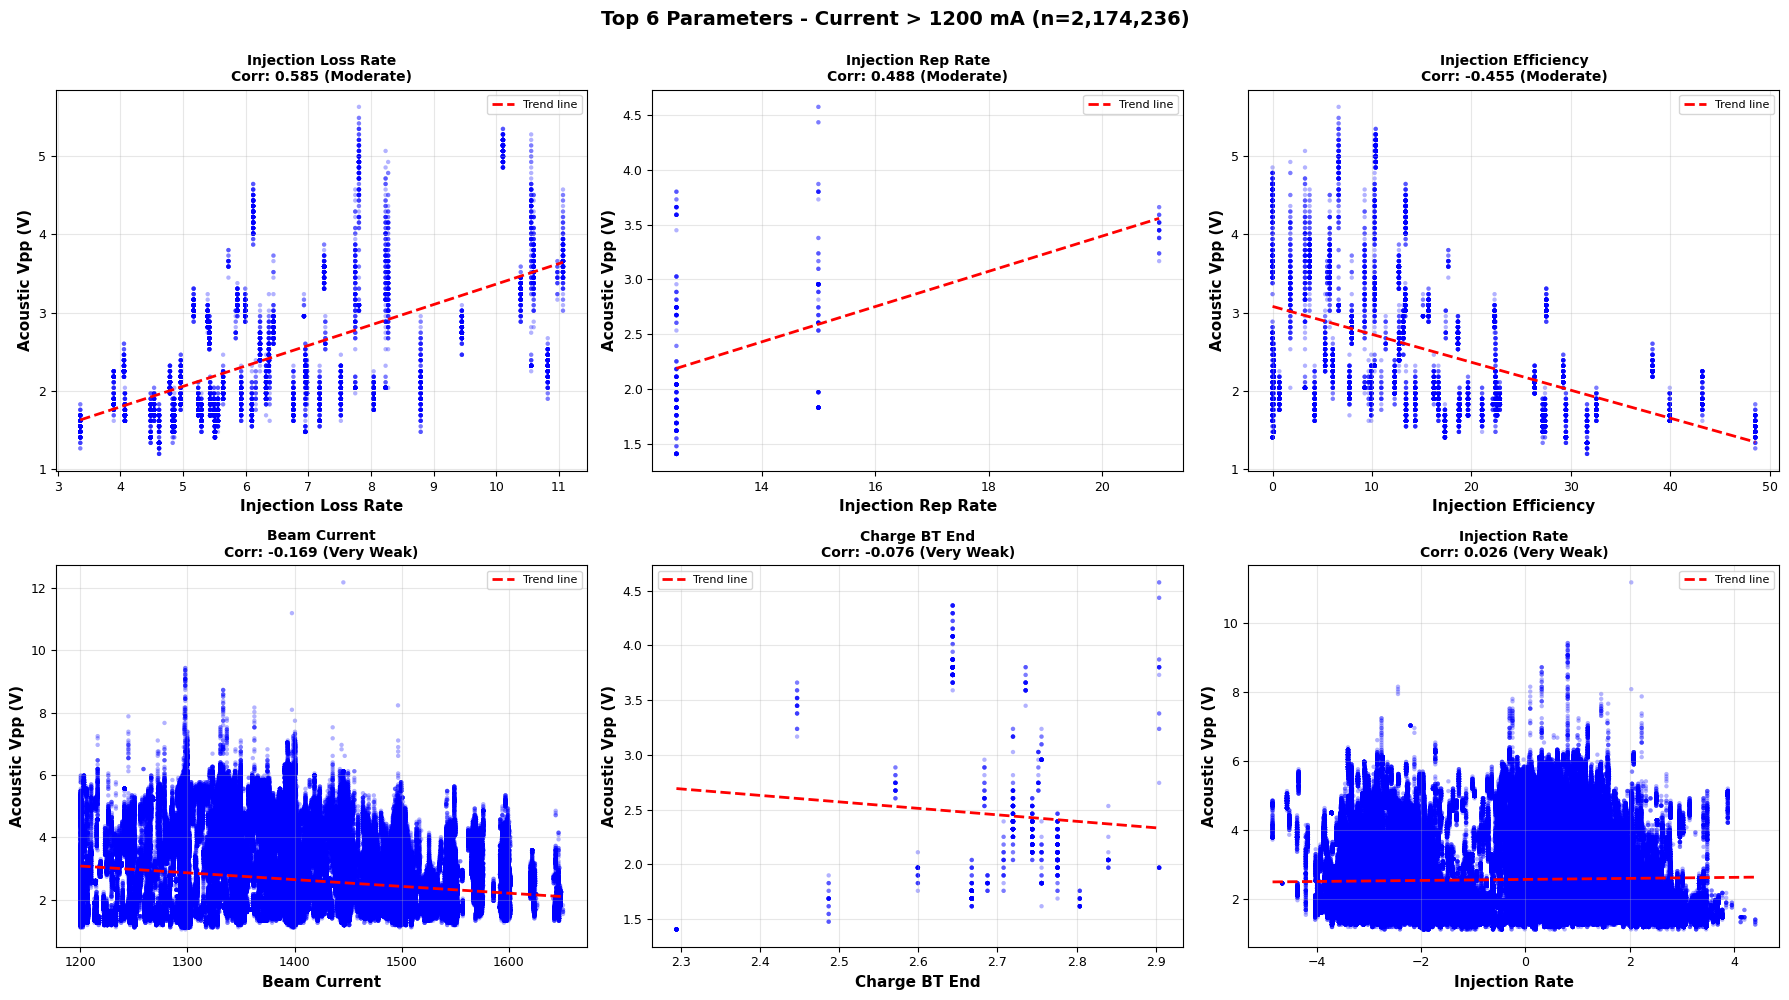


✓ Single-case scatter plot analysis complete! (Current > 1200 mA only)
Saved plots:
  - correlation_scatter_current_gt_1200_ma.png


In [76]:
# CELL 6: Scatter plots for top 6 parameters in each of 4 cases

print("="*80)
print("SCATTER PLOT ANALYSIS - 4 CASE COMPARISON")
print("="*80)

# Create a plot only for the 1200 mA case
for case_idx, case in enumerate([c for c in cases if c['lower'] == 1200], 1):
    case_label = case['label']
    lower = case['lower']
    upper = case['upper']
    
    print(f"\nGenerating scatter plots for: {case_label}")
    
    # Filter data based on current range
    filtered_df = all_merged_df.copy()
    
    if lower is not None:
        filtered_df = filtered_df[filtered_df['A_BM_Current_mA'] >= lower]
    if upper is not None:
        filtered_df = filtered_df[filtered_df['A_BM_Current_mA'] <= upper]
    
    # Get correlations for this case
    corr_dict = case_correlations[case_label]
    
    # Get top 6 by absolute correlation
    top_params = sorted(corr_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:6]
    n_plots = len(top_params)
    
    # Create 2x3 grid
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for plot_idx in range(n_plots):
        param, corr = top_params[plot_idx]
        ax = axes[plot_idx]
        
        # Get valid data points
        valid_mask = filtered_df['vpp_volts'].notna() & filtered_df[param].notna()
        x_data = filtered_df.loc[valid_mask, param]
        y_data = filtered_df.loc[valid_mask, 'vpp_volts']
        
        # Create scatter plot with all data points
        ax.scatter(x_data, y_data, alpha=0.3, s=10, c='blue', edgecolors='none')
        
        # Add trend line
        z = np.polyfit(x_data, y_data, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(x_data.min(), x_data.max(), 100)
        ax.plot(x_trend, p(x_trend), "r--", linewidth=2, label='Trend line')
        
        # Labels and title
        param_display = param_names.get(param, param)
        ax.set_xlabel(param_display, fontsize=11, fontweight='bold')
        ax.set_ylabel('Acoustic Vpp (V)', fontsize=11, fontweight='bold')
        ax.set_title(f'{param_display}\nCorr: {corr:.3f} ({corr_strength(corr)})', 
                    fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=9)
        ax.legend(fontsize=8)
        
        print(f"  ✓ {param_display}: {len(x_data)} points, r={corr:.3f}")
    
    # Hide unused subplots
    for plot_idx in range(n_plots, 6):
        axes[plot_idx].axis('off')
    
    fig.suptitle(f'Top 6 Parameters - {case_label} (n={len(filtered_df):,})', 
                fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    # Save with case-specific filename
    case_filename = case_label.lower().replace(' ', '_').replace('>', 'gt')
    plt.savefig(f'/Users/xylu/Desktop/Data/acoustic_vpp/daily_plots/correlation_scatter_{case_filename}.png', 
               dpi=150, bbox_inches='tight')
    plt.show()
    
print("\n" + "="*80)
print("✓ Single-case scatter plot analysis complete! (Current > 1200 mA only)")
print("Saved plots:")
for case in [c for c in cases if c['lower'] == 1200]:
    case_filename = case['label'].lower().replace(' ', '_').replace('>', 'gt')
    print(f"  - correlation_scatter_{case_filename}.png")